# DeepExtractor — Training Tutorial (Google Colab)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tomdooney95/deepextractor/blob/main/notebooks/training_tutorial_colab.ipynb)

This notebook trains a fresh DeepExtractor model from scratch on synthetic (`numpy`) noise, plots the training losses, and tests the model on sine-Gaussian injections. It is designed to run on Google Colab with a free T4 GPU.

> **Tip:** Go to Runtime → Change runtime type → GPU before running.

## Overview

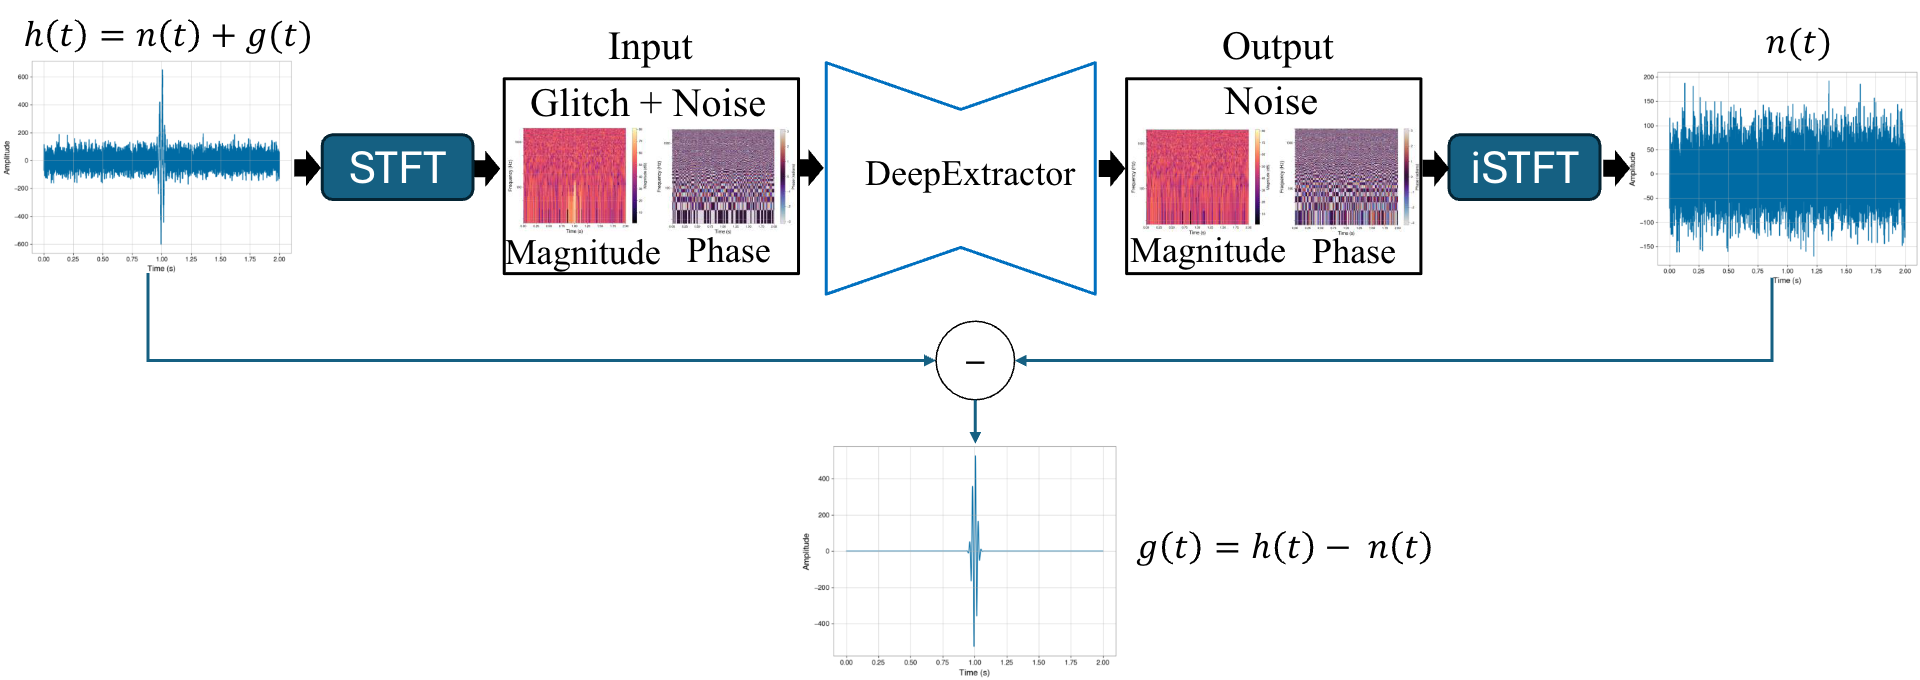

**Figure 1 — DeepExtractor pipeline.** The raw strain $h(t) = n(t) + g(t)$ (background noise
plus an injected glitch) is converted to a magnitude + phase spectrogram via STFT, passed
through the DeepExtractor U-Net, and the predicted *clean-noise* spectrogram is converted back
to the time domain via iSTFT to give the reconstructed background $n(t)$. The recovered
glitch/residual is then $g(t) = h(t) - n(t)$ — this is exactly what Steps 1–6 below build and
train, on synthetic data.

| Part | What |
|------|------|
| **Part I — Introduction** | Build the full DeepExtractor pipeline from scratch: synthetic data generation, STFT U-Net, training loop, reconstruction on sine-Gaussian injections. Fully worked — run top to bottom for a working baseline model. |
| **Part II — Hackathon Tasks** | Four hands-on exercises: model depth, time-domain vs. STFT architecture, training-set size, and generalisation to unseen signal types. |
| **Part III — MC-Dropout Uncertainty Showcase** | Get uncertainty estimates "for free" by leaving dropout on at test time — reconstruct a real detector glitch with confidence bands, no extra training needed. |
| **Part IV — Bonus: Reconstructing a Real CBC Waveform** | Take a genuine PyCBC-simulated compact-binary waveform, reshape it to resemble a longer-duration coalescence, and reconstruct it with the already-trained model. |

**Part II TODO Exercises:**

* **Task 1** — build + train a `UNET2D` at a different depth (`features_configs`), evaluate mismatch
* **Task 2** — build + train a `UNET1D` (time-domain) and compare against the STFT baseline
* **Task 3** — build + train a `UNET2D` at varying `N_TRAIN` sizes, evaluate mismatch
* **Task 4** — build + train Model A and Model B on different signal-type mixes, compare generalisation

Everything in Parts I, III, and IV is fully solved and runnable as-is — Part II is where you write code.

In [31]:
!pip install deepextractor gengli

In [32]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.preprocessing import StandardScaler
from torch.optim.lr_scheduler import ReduceLROnPlateau
from tqdm.auto import tqdm
import random

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

## Configuration

In [ ]:
# Reproducibility — seeds numpy/torch/random so a fresh top-to-bottom run
# matches (more or less) the reference outputs already shown in this notebook.
SEED = 40
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Signal / data constants
SAMPLE_RATE = 4096                 # Hz
T           = 2.0                  # seconds per training window
LENGTH      = int(T * SAMPLE_RATE) # samples per window = 8192

# Device — uses MPS on Apple Silicon, CUDA on Linux/Windows GPU, otherwise CPU
if torch.cuda.is_available():
    DEVICE = "cuda"
elif torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = "cpu"
print(f"Using device: {DEVICE}")

# Dataset size — keep small for a quick demo; increase for better performance
N_TRAIN = 1000
N_VAL   = 200

# Training
BATCH_SIZE              = 32
EPOCHS                  = 30    # maximum epochs; early stopping may stop sooner however, this specific architecture will likely converge at a much higher epoch
LR                      = 1e-4
LR_PATIENCE             = 2     # epochs without improvement before LR is reduced
LR_FACTOR               = 0.1   # factor to reduce LR by
EARLY_STOPPING_PATIENCE = 5     # epochs without improvement before training stops
DROPOUT_P               = 0.1   # MC-Dropout (decoder + bottleneck only) — baked into every
                                 # model below so Part III can showcase it at test time
                                 # without a separate training run; see Part III for why.

# STFT parameters
# Original DeepExtractor (arXiv:2501.18423): N_FFT=512, WIN_LENGTH=64, HOP_LENGTH=32
# → produces (257, 257) spectrograms, richer time-frequency representation
#   but significantly slower to train.
# Tutorial default: smaller spectrograms for faster training, but still gives decent performance (please see 129x129 model in the paper).
N_FFT      = 256
WIN_LENGTH = N_FFT // 2
HOP_LENGTH = WIN_LENGTH // 2

# Physical time axis — Mojito/LISA-compatible (0.5 Hz, dt = 2.0 s per sample)
DT         = 1.0 / 0.5          # seconds per sample  =  2.0 s
T_PHYSICAL = LENGTH * DT        # total window duration = 16384 s


Using device: mps


# Part I — Introduction

## Step 1 — Generate synthetic time-domain data

Each training sample is a pair:
- **Input** `glitch`: background noise with 1–30 synthetic signal injections (chirps, sine-Gaussians, etc.)
- **Target** `background`: the same noise without any injections

The model learns to map glitchy strain → clean background.

### Signal generators

The five synthetic "glitch" types injected into the noise below

In [34]:
from scipy.signal import chirp, gausspulse


def quality_factor_conversion(Q, f_0):
    """Convert quality factor Q and central frequency f_0 to decay time tau."""
    return Q / (np.sqrt(2) * np.pi * f_0)


def rescale(x):
    """Rescale each row of x to the range [-1, 1]."""
    abs_max = np.max(np.abs(x), axis=1, keepdims=True)
    return x / abs_max


def generate_chirp(duration, sample_rate=SAMPLE_RATE, f0_min=1, f0_max=SAMPLE_RATE // 2,
                   f1_min=1, f1_max=SAMPLE_RATE // 2):
    f0 = np.random.uniform(f0_min, f0_max)
    f1 = np.random.uniform(f1_min, f1_max)
    t = np.linspace(0, duration, int(sample_rate * duration), endpoint=False)
    signal = chirp(t, f0=f0, f1=f1, t1=duration, method="linear")
    return t, signal


def generate_sine(duration, sample_rate=SAMPLE_RATE, freq_min=1, freq_max=SAMPLE_RATE // 2):
    frequency = np.random.uniform(freq_min, freq_max)
    t = np.linspace(0, duration, int(sample_rate * duration), endpoint=False)
    signal = np.sin(2 * np.pi * frequency * t)
    return t, signal


def generate_sine_gaussian(duration, sample_rate=SAMPLE_RATE, freq_min=1, freq_max=SAMPLE_RATE // 2):
    tau = np.random.uniform(duration / 200, duration / 4)
    frequency = np.random.uniform(freq_min, freq_max)
    t = np.linspace(-duration / 2, duration / 2, int(sample_rate * duration), endpoint=False)
    signal = np.sin(2 * np.pi * frequency * t) * np.exp(-(t**2) / (2 * tau**2))
    return t, signal


def generate_gaussian_pulse(duration, sample_rate=SAMPLE_RATE, fc_min=1, fc_max=SAMPLE_RATE // 2,
                             bw_min=0.1, bw_max=1.0, bwr_min=-10, bwr_max=0,
                             tpr_min=0.5, tpr_max=2.0):
    """Generate a Gaussian pulse with random parameters."""
    bw = np.random.uniform(bw_min, bw_max)
    fc = np.random.uniform(fc_min, fc_max)
    bwr = np.random.uniform(bwr_min, bwr_max)
    tpr = np.random.uniform(tpr_min, tpr_max)
    t = np.linspace(-duration / 2, duration / 2, int(sample_rate * duration), endpoint=False)
    signal = gausspulse(t, fc=fc, bw=bw, bwr=bwr, tpr=tpr)
    return t, signal


def ringdown(duration, sample_rate=SAMPLE_RATE, n_signals=1):
    t = np.linspace(0, duration, int(sample_rate * duration))
    phi = np.random.uniform(0, 2 * np.pi)
    A = 1.0
    f_0 = np.random.uniform(10, SAMPLE_RATE // 2, n_signals)
    t_0 = np.random.uniform(t[-1] / 4, 3 * t[-1] / 4, n_signals)
    Q = np.random.uniform(5, 150, n_signals)
    tau = np.maximum(quality_factor_conversion(Q, f_0), 0.01)
    f_0 = np.expand_dims(f_0, axis=1)
    t_0 = np.expand_dims(t_0, axis=1)
    tau = np.expand_dims(tau, axis=1)
    h_1 = A * np.exp(-1.0 * ((t - t_0) / (tau))) * np.sin(2 * np.pi * f_0 * (t - t_0) + phi)
    h_1 = ((t - t_0) > 0) * h_1
    h_1 = rescale(h_1)
    if np.random.rand() < 0.5:
        h_1 = np.flip(h_1)
    return t, h_1[0]

**Figure 2 — the five basis waveform types** used to build the synthetic training set below.
Each training example injects 1–30 of these (randomly chosen type, duration, frequency, and
SNR) into background noise — this is *what* Step 1 fills the noise with. The same gallery
reappears later in Task 4, where you'll train on different subsets of these types and test
how well each generalises.

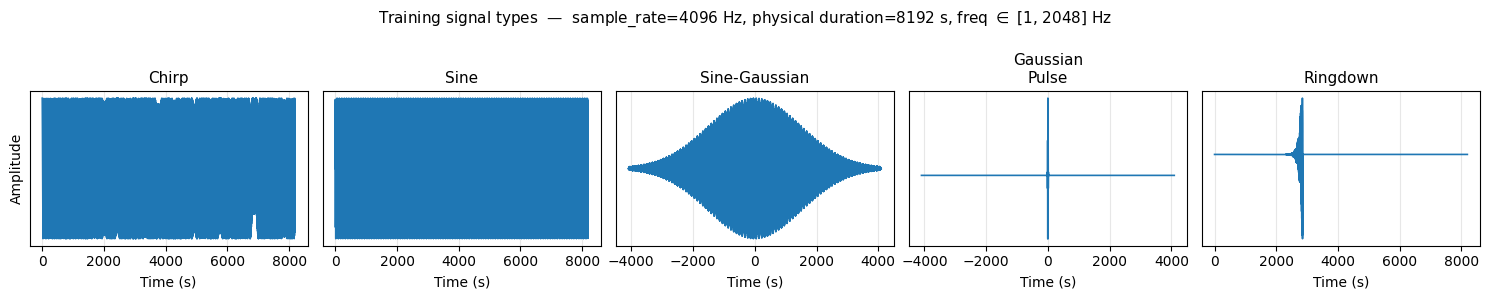

In [35]:
# Basis waveform gallery (reuses the generators defined just above; same code
# used again in Task 4)
np.random.seed(7)
_NYQUIST  = SAMPLE_RATE // 2   # 2048 Hz
_DURATION = 1.0                # seconds at SAMPLE_RATE; physical duration = _DURATION * SAMPLE_RATE * DT

_t_ch, _s_ch = generate_chirp(
    _DURATION, sample_rate=SAMPLE_RATE, f0_min=1, f0_max=_NYQUIST, f1_min=1, f1_max=_NYQUIST)
_t_si, _s_si = generate_sine(
    _DURATION, sample_rate=SAMPLE_RATE, freq_min=1, freq_max=_NYQUIST)
_t_sg, _s_sg = generate_sine_gaussian(
    _DURATION, sample_rate=SAMPLE_RATE, freq_min=1, freq_max=_NYQUIST)
_t_gp, _s_gp = generate_gaussian_pulse(
    _DURATION, sample_rate=SAMPLE_RATE, fc_min=1, fc_max=_NYQUIST)
_t_rd, _s_rd = ringdown(
    _DURATION, sample_rate=SAMPLE_RATE)   # freq drawn internally from [10, NYQUIST]

_gallery = [
    (_t_ch, _s_ch, "Chirp"),
    (_t_si, _s_si, "Sine"),
    (_t_sg, _s_sg, "Sine-Gaussian"),
    (_t_gp, _s_gp, "Gaussian\nPulse"),
    (_t_rd, _s_rd, "Ringdown"),
]

_phys_dur = _DURATION * SAMPLE_RATE * DT  # physical duration in seconds

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for ax, (t, sig, name) in zip(axes, _gallery):
    ax.plot(t * SAMPLE_RATE * DT, sig, lw=1.2, color="C0")
    ax.set_title(name, fontsize=11)
    ax.set_xlabel("Time (s)")
    ax.set_yticks([])
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Amplitude")
fig.suptitle(
    f"Training signal types  —  sample_rate={SAMPLE_RATE} Hz, "
    f"physical duration={_phys_dur:.0f} s, freq $\\in$ [1, {_NYQUIST}] Hz",
    fontsize=11,
)
plt.tight_layout()
plt.show()

### Noise + injection generation

Background noise and the injection logic that combines it with the signals
above — also defined here rather than imported.

In [36]:
T_INJ = T / 2
SNR_MIN, SNR_MAX = 1, 250
SNR_SCALING_FACTOR_BILBY = np.sqrt(SAMPLE_RATE / 2)  # only used if bilby_noise=True (not used below)

SIGNAL_TYPES = ["chirp", "sine", "sine_gaussian", "gaussian_pulse", "ringdown"]
SIGNAL_FUNCTION_MAP = {
    "chirp": generate_chirp,
    "sine": generate_sine,
    "sine_gaussian": generate_sine_gaussian,
    "gaussian_pulse": generate_gaussian_pulse,
    "ringdown": ringdown,
}


def whitened_snr_scaling(glitch, snr, srate=SAMPLE_RATE):
    """Scale a glitch signal to the target SNR relative to zero-mean,
    unit-variance background noise.

    The matched-filter formula below (true_sigma_sq) implicitly assumes a flat
    one-sided PSD of Sn(f)=1, which for discrete white noise corresponds to a
    time-domain variance of srate/2 (Sn = 2*sigma**2/srate => sigma = sqrt(srate/2)),
    not the unit variance our noise actually uses. Dividing by sqrt(srate/2)
    corrects for that mismatch
    """
    glitch = np.asarray(glitch)
    if snr is not None:
        df = srate / glitch.shape[-1]
        glitch_FD = np.fft.rfft(glitch, axis=-1) / srate
        true_sigma_sq = 4.0 * df * np.sum(np.multiply(np.conj(glitch_FD), glitch_FD), axis=-1).real
        glitch = (glitch.T * snr / np.sqrt(true_sigma_sq)).T
        glitch = glitch / np.sqrt(srate / 2)
    return glitch


def generate_gaussian_noise(mean, std_dev, num_samples, sample_shape, bilby_noise=False,
                            sample_rate=SAMPLE_RATE, duration=T,
                            minimum_frequency=20.0, detector="L1"):
    """Generate Gaussian noise samples (pycbc-style or bilby)."""
    if bilby_noise:
        import bilby
        gaussian_noise_samples = []
        for i in tqdm(range(num_samples), desc="Generating bilby noise..."):
            ifos = bilby.gw.detector.InterferometerList([detector])
            for ifo in ifos:
                ifo.minimum_frequency = minimum_frequency
            ifos.set_strain_data_from_power_spectral_densities(
                sampling_frequency=sample_rate, duration=duration, start_time=0,
            )
            white_time_domain_strain = list(ifos[0].whitened_time_domain_strain)
            gaussian_noise_samples.append(white_time_domain_strain)
        return np.asarray(gaussian_noise_samples)
    else:
        print("Generating noise...")
        return np.random.normal(loc=mean, scale=std_dev, size=(num_samples, *sample_shape))


def generate_synthetic_data(gaussian_noise_samples, bilby_noise=False, phase="train",
                             t_min=0.125, t_max=2.0, snr_min=SNR_MIN, snr_max=SNR_MAX):
    """Generate synthetic noisy glitch and background data arrays."""
    noisy_glitch_ts = []
    pure_noise_ts = []

    for i in tqdm(range(len(gaussian_noise_samples)),
                  desc=f"Generating Synthetic {phase.capitalize()} Data"):
        background = gaussian_noise_samples[i]
        noisy_glitch = background.copy()
        n_injs = np.random.randint(1, 30)
        for _ in range(n_injs):
            snr_to_scale = np.random.uniform(snr_min, snr_max)
            if bilby_noise:
                snr_to_scale = snr_to_scale / SNR_SCALING_FACTOR_BILBY
            duration = np.random.uniform(t_min, t_max)
            s_type = random.choice(SIGNAL_TYPES)
            _, signal_injection = SIGNAL_FUNCTION_MAP[s_type](duration)
            len_glitch = len(signal_injection)
            id_start = int((T_INJ * SAMPLE_RATE / LENGTH) * len(background)) - len_glitch // 2
            glitch = signal_injection - np.mean(signal_injection)
            glitch = whitened_snr_scaling(glitch, snr=snr_to_scale)
            shift_int = np.random.randint(-id_start, len(background) - id_start - len_glitch)
            noisy_glitch[id_start + shift_int:id_start + len_glitch + shift_int] += glitch

        noisy_glitch_ts.append(noisy_glitch)
        pure_noise_ts.append(background)

    noisy_glitch_ts = np.asarray(noisy_glitch_ts)
    pure_noise_ts = np.asarray(pure_noise_ts)

    mask = ~np.any(
        np.isnan(noisy_glitch_ts) | np.isinf(noisy_glitch_ts)
        | (np.abs(noisy_glitch_ts) > np.finfo(np.float64).max),
        axis=1,
    )
    return noisy_glitch_ts[mask], pure_noise_ts[mask]

In [37]:
mean, std_dev = 0, 1  # zero-mean, unit variance — matches whitened_snr_scaling's flat-PSD=1 assumption

print("Generating training noise...")
train_noise = generate_gaussian_noise(mean, std_dev, N_TRAIN, (LENGTH,), bilby_noise=False)
print("Generating validation noise...")
val_noise   = generate_gaussian_noise(mean, std_dev, N_VAL,   (LENGTH,), bilby_noise=False)

print("Generating training pairs...")
glitch_train, bg_train = generate_synthetic_data(train_noise, bilby_noise=False, phase="train")
print("Generating validation pairs...")
glitch_val,   bg_val   = generate_synthetic_data(val_noise,   bilby_noise=False, phase="val")

print(f"\nTrain: {glitch_train.shape}  |  Val: {glitch_val.shape}")

Generating training noise...
Generating noise...
Generating validation noise...
Generating noise...
Generating training pairs...


Generating Synthetic Train Data: 100%|██████████| 1000/1000 [00:02<00:00, 359.75it/s]


Generating validation pairs...


Generating Synthetic Val Data: 100%|██████████| 200/200 [00:00<00:00, 379.67it/s]


Train: (1000, 8192)  |  Val: (200, 8192)


### Visualize one training example

Before scaling and computing spectrograms for the full dataset, let's look at a single
training pair: the raw time series and its STFT magnitude/phase spectrograms.

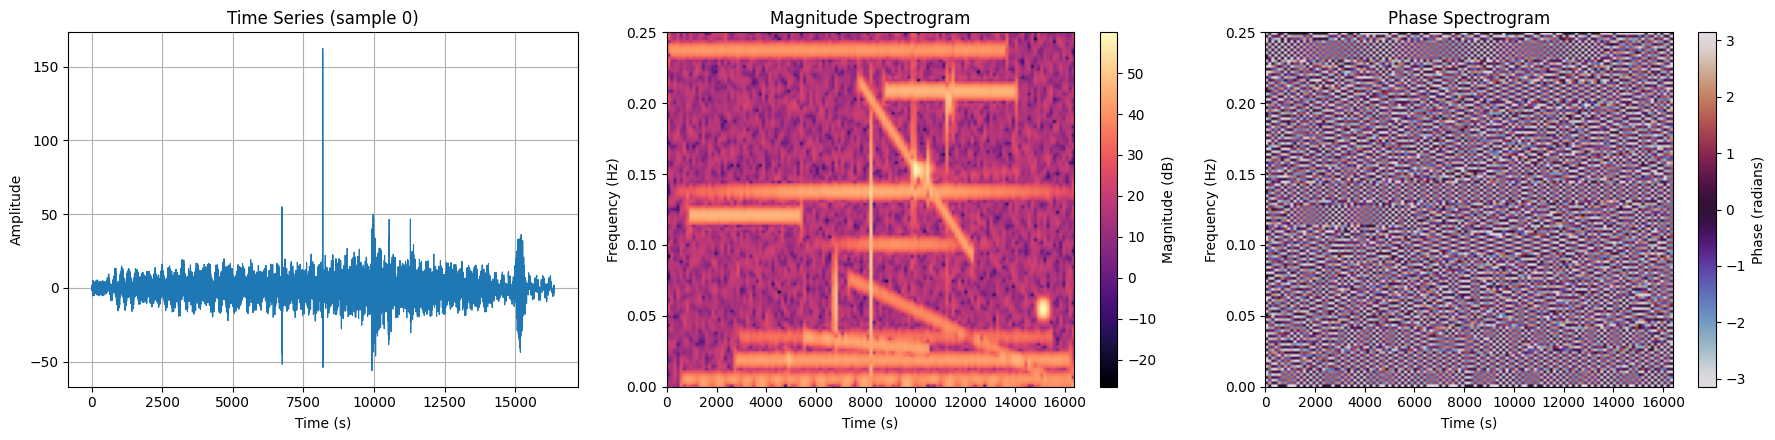

In [38]:
# Visualize one example: raw time series and its STFT magnitude/phase spectrograms
sample_idx    = 0
glitch_sample = glitch_train[sample_idx]

window_viz = torch.hann_window(WIN_LENGTH)
stft_sample = torch.stft(
    torch.tensor(glitch_sample, dtype=torch.float32),
    n_fft=N_FFT, hop_length=HOP_LENGTH, win_length=WIN_LENGTH,
    window=window_viz, return_complex=True,
)
mag_sample    = torch.abs(stft_sample).numpy()
phase_sample  = torch.angle(stft_sample).numpy()
mag_sample_db = 20 * np.log10(mag_sample + 1e-8)

# Axes — consistent with the LISA-compatible time labeling used elsewhere in this notebook
t_axis         = np.arange(LENGTH) * DT
freq_axis      = np.linspace(0, 0.5 / DT, mag_sample.shape[0])
time_axis_spec = np.linspace(0, LENGTH * DT, mag_sample.shape[1])

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

axes[0].plot(t_axis, glitch_sample, color="C0", lw=0.8)
axes[0].set_title(f"Time Series (sample {sample_idx})")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Amplitude")
axes[0].grid(True)

im1 = axes[1].imshow(
    mag_sample_db, aspect="auto", origin="lower", cmap="magma",
    extent=[time_axis_spec[0], time_axis_spec[-1], freq_axis[0], freq_axis[-1]],
)
axes[1].set_title("Magnitude Spectrogram")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Frequency (Hz)")
fig.colorbar(im1, ax=axes[1], label="Magnitude (dB)")

im2 = axes[2].imshow(
    phase_sample, aspect="auto", origin="lower", cmap="twilight",
    extent=[time_axis_spec[0], time_axis_spec[-1], freq_axis[0], freq_axis[-1]],
    vmin=-np.pi, vmax=np.pi,
)
axes[2].set_title("Phase Spectrogram")
axes[2].set_xlabel("Time (s)")
axes[2].set_ylabel("Frequency (Hz)")
fig.colorbar(im2, ax=axes[2], label="Phase (radians)")

plt.tight_layout()
plt.show()

## Step 2 — Scale and convert to spectrograms

In [39]:
# We fit the scaler to the noise+glitch training data, then apply the same transformation to the training and validation data. 
# This ensures that the model sees inputs with similar distributions during training and validation.
scaler = StandardScaler()
glitch_train_scaled = scaler.fit_transform(glitch_train.reshape(-1, 1)).reshape(glitch_train.shape)
bg_train_scaled     = scaler.transform(bg_train.reshape(-1, 1)).reshape(bg_train.shape)
glitch_val_scaled   = scaler.transform(glitch_val.reshape(-1, 1)).reshape(glitch_val.shape)
bg_val_scaled       = scaler.transform(bg_val.reshape(-1, 1)).reshape(bg_val.shape)

# Uncomment to save the scaler for use outside this notebook
# import pickle, os
# os.makedirs('/tmp/de_training_tutorial', exist_ok=True)
# with open('/tmp/de_training_tutorial/scaler.pkl', 'wb') as f:
#     pickle.dump(scaler, f)

# Convert to STFT spectrograms (in-memory)
window = torch.hann_window(WIN_LENGTH)

def to_mag_phase(arrays):
    """Convert a numpy array (N, time) to a (N, 2, F, T) mag/phase tensor."""
    t = torch.tensor(arrays, dtype=torch.float32)
    stft = torch.stft(t, n_fft=N_FFT, hop_length=HOP_LENGTH, win_length=WIN_LENGTH,
                      window=window, return_complex=True)
    mag   = torch.abs(stft)
    phase = torch.angle(stft)
    return torch.stack([mag, phase], dim=1)  # (N, 2, F, T)

glitch_train_spec = to_mag_phase(glitch_train_scaled)
bg_train_spec     = to_mag_phase(bg_train_scaled)
glitch_val_spec   = to_mag_phase(glitch_val_scaled)
bg_val_spec       = to_mag_phase(bg_val_scaled)

print(f"Spectrogram shape: {glitch_train_spec.shape}  — (N, 2, freq_bins, time_bins)")

# Uncomment to save spectrograms to disk (useful for large datasets or re-use)
# os.makedirs('/tmp/de_training_tutorial/spectrogram_domain', exist_ok=True)
# for name, arr in [
#     ('glitch_train_scaled_mag_phase',     glitch_train_spec.numpy()),
#     ('background_train_scaled_mag_phase', bg_train_spec.numpy()),
#     ('glitch_val_scaled_mag_phase',       glitch_val_spec.numpy()),
#     ('background_val_scaled_mag_phase',   bg_val_spec.numpy()),
# ]:
#     np.save(f'/tmp/de_training_tutorial/spectrogram_domain/{name}', arr)


Spectrogram shape: torch.Size([1000, 2, 129, 129])  — (N, 2, freq_bins, time_bins)


## Step 3 — Build model and data loaders

**Figure 3 — the `UNET2D` architecture** trained below: a 4-level encoder–decoder with
`DoubleConv` blocks, skip connections between corresponding encoder/decoder levels
(concatenated, ⊕), and a `DoubleConv` bottleneck at the base. Input and output are both
`(batch, 2, freq_bins, time_bins)` magnitude + phase spectrograms — the same 2-channel
representation visualized in Step 1 above. Each decoder level upsamples with
`ConvTranspose2d` before its `DoubleConv`; a final 1×1 `Conv2d` maps the last decoder
features back to 2 output channels.

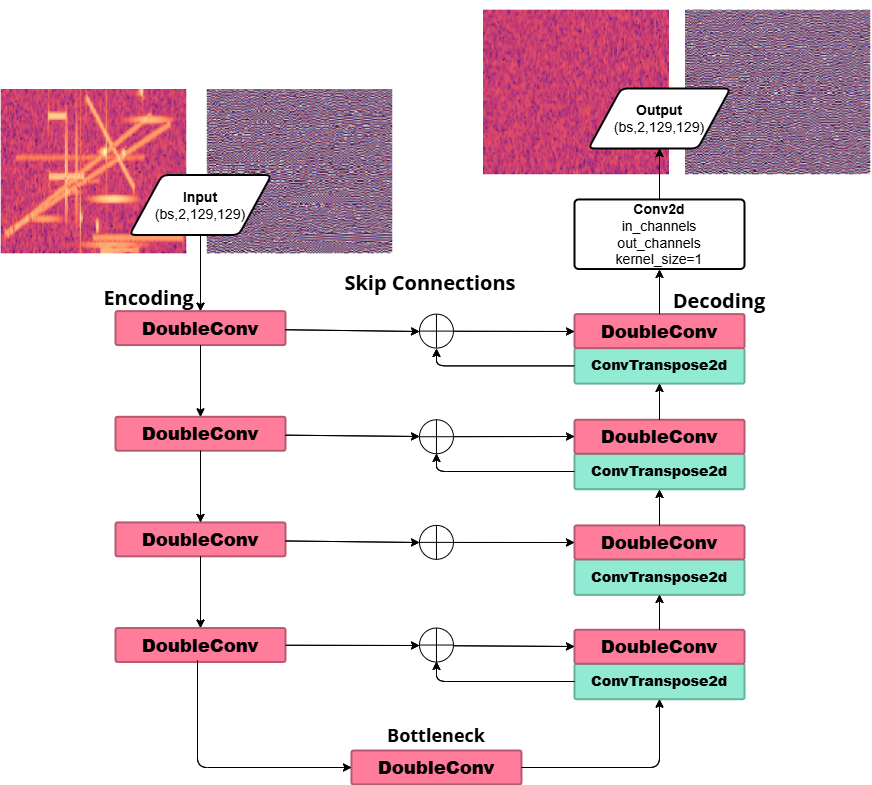

In [40]:
class DoubleConv2D(nn.Module):
    def __init__(self, in_channels, out_channels, dropout_p=0.0):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )
        # Dropout applied after the conv block (not inserted into the Sequential)
        # so existing checkpoints trained with dropout_p=0.0 still load cleanly —
        # Dropout2d has no weights/buffers, so it adds no state_dict keys either way.
        self.dropout = nn.Dropout2d(dropout_p) if dropout_p > 0.0 else None

    def forward(self, x):
        x = self.conv(x)
        if self.dropout is not None:
            x = self.dropout(x)
        return x


class UNET2D(nn.Module):
    """4-level encoder/decoder U-Net operating on (B, C, freq_bins, time_bins)
    spectrograms, with skip connections between matching encoder/decoder levels —
    see Figure 3 above.

    dropout_p (default 0.0, i.e. off): enables Monte Carlo Dropout for uncertainty
    estimation — see the MC-Dropout showcase near the end of this notebook. Only
    the decoder + bottleneck get dropout; the encoder never does, so it keeps
    learning stable feature detectors regardless of dropout_p.
    """
    def __init__(self, in_channels=2, out_channels=2, features=[64, 128, 256, 512],
                 dropout_p=0.0):
        super().__init__()
        self.ups = nn.ModuleList()
        self.downs = nn.ModuleList()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        for feature in features:
            self.downs.append(DoubleConv2D(in_channels, feature, dropout_p=0.0))
            in_channels = feature

        for feature in reversed(features):
            self.ups.append(nn.ConvTranspose2d(feature * 2, feature, kernel_size=2, stride=2))
            self.ups.append(DoubleConv2D(feature * 2, feature, dropout_p=dropout_p))

        self.bottleneck = DoubleConv2D(features[-1], features[-1] * 2, dropout_p=dropout_p)
        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        skip_connections = []
        for down in self.downs:
            x = down(x)
            skip_connections.append(x)
            x = self.pool(x)

        x = self.bottleneck(x)
        skip_connections = skip_connections[::-1]

        for idx in range(0, len(self.ups), 2):
            x = self.ups[idx](x)
            skip_connection = skip_connections[idx // 2]
            if x.shape != skip_connection.shape:
                x = F.interpolate(x, size=skip_connection.shape[2:])
            concat_skip = torch.cat((skip_connection, x), dim=1)
            x = self.ups[idx + 1](concat_skip)

        return self.final_conv(x)

In [41]:
from torch.utils.data import TensorDataset, DataLoader

# Model architecture
# Original DeepExtractor (arXiv:2501.18423): features=[64, 128, 256, 512] — ~31M parameters.
# Use those to train a model equivalent to the published DeepExtractor.
# Tutorial default: one fewer layer and half the filters for faster training.
model = UNET2D(in_channels=2, out_channels=2, features=[32, 64, 128, 256],
              dropout_p=DROPOUT_P).to(DEVICE)
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

train_ds = TensorDataset(glitch_train_spec, bg_train_spec)
val_ds   = TensorDataset(glitch_val_spec,   bg_val_spec)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_loader)}  |  Val batches: {len(val_loader)}")
print(f"Spectrogram shape: {glitch_train_spec.shape}  — (N, 2, freq_bins, time_bins)")


Model parameters: 7,762,786
Train batches: 32  |  Val batches: 7
Spectrogram shape: torch.Size([1000, 2, 129, 129])  — (N, 2, freq_bins, time_bins)


In [42]:
# The function below implements the full reconstruction pipeline: 
# scaling the input, computing its STFT, passing it through the U-Net model, performing the inverse STFT, 
# unscaling the output, and finally subtracting the predicted background from the original noisy signal to recover the glitch signal.
def reconstruct(noisy_signal, model, scaler, device, n_fft, hop_length, win_length):
    """Scale → STFT → U-Net → iSTFT → unscale → subtract background."""
    # Scale
    scaled = scaler.transform(noisy_signal.reshape(-1, 1)).reshape(noisy_signal.shape)

    # STFT
    window = torch.hann_window(win_length)
    t = torch.tensor(scaled, dtype=torch.float32).unsqueeze(0)  # (1, time)
    stft = torch.stft(t, n_fft=n_fft, hop_length=hop_length, win_length=win_length,
                      window=window, return_complex=True)
    mag   = torch.abs(stft)
    phase = torch.angle(stft)
    spec  = torch.stack([mag, phase], dim=1)  # (1, 2, F, T)

    # U-Net inference
    model.eval()
    with torch.no_grad():
        bg_spec = model(spec.to(device)).cpu()  # predicted background spectrogram

    # iSTFT
    bg_mag   = bg_spec[:, 0, :, :]
    bg_phase = bg_spec[:, 1, :, :]
    bg_complex = bg_mag * torch.exp(1j * bg_phase)
    bg_td = torch.istft(bg_complex, n_fft=n_fft, hop_length=hop_length,
                        win_length=win_length, window=window,
                        length=noisy_signal.shape[-1])

    # Unscale and subtract background to recover signal
    bg_unscaled = scaler.inverse_transform(bg_td.numpy().reshape(-1, 1)).reshape(-1)
    noisy_unscaled = noisy_signal.copy()
    reconstruction = noisy_unscaled - bg_unscaled
    return reconstruction

## Step 4 — Train

We train the network for up to `EPOCHS` iterations. For this minimal tutorial configuration
(1000 samples, reduced model), 50 epochs is sufficient to see the loss converge.
To train a model to full convergence, set `EPOCHS` to a large number (e.g. 200) — the learning rate
scheduler and early stopping will halt training automatically once the validation loss stops
improving. We recommend using a CUDA GPU (e.g. Google Colab).


In [43]:
def train_fn(loader, model, optimizer, loss_fn, amp_scaler, device):
    """Train the model for one epoch; returns the average training loss."""
    loop = tqdm(loader, desc="Training on batch")
    epoch_loss = 0
    for data, targets in loop:
        data = data.to(device=device)
        targets = targets.float().to(device=device)

        autocast_device = "cuda" if device.startswith("cuda") else "cpu"
        with torch.amp.autocast(autocast_device):
            predictions = model(data)
            loss = loss_fn(predictions, targets)

        optimizer.zero_grad()
        amp_scaler.scale(loss).backward()
        amp_scaler.step(optimizer)
        amp_scaler.update()

        epoch_loss += loss.item()
        loop.set_postfix(loss=loss.item())

    return epoch_loss / len(loader)


def check_accuracy(loader, model, device="cuda"):
    """Compute the mean MSE loss over a validation/test loader."""
    mse_loss_fn = nn.MSELoss()
    total_loss = 0.0
    num_samples = 0
    model.eval()

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)
            predictions = model(x)
            loss = mse_loss_fn(predictions, y)
            total_loss += loss.item() * x.size(0)
            num_samples += x.size(0)

    model.train()
    avg_loss = total_loss / num_samples
    print(f"Validation Loss: {avg_loss:.6f}")
    return avg_loss

In [44]:
# Fixed sine-Gaussian example used to visualize reconstruction quality across
# epochs — the training loop below reconstructs this same example after every
# epoch so we can turn the sequence into a GIF (see after the loop).
_gif_noise = generate_gaussian_noise(mean, std_dev, 1, (LENGTH,), bilby_noise=False)[0]
_, _gif_sg = generate_sine_gaussian(duration=0.5, freq_max=64)
_gif_sg    = _gif_sg - np.mean(_gif_sg)
_gif_sg    = whitened_snr_scaling(_gif_sg, snr=80)
_gif_L     = len(_gif_sg)
_gif_i0    = int(T_INJ * SAMPLE_RATE) - _gif_L // 2
_gif_noisy = _gif_noise.copy()
_gif_noisy[_gif_i0:_gif_i0 + _gif_L] += _gif_sg
_gif_inj   = np.zeros(LENGTH)
_gif_inj[_gif_i0:_gif_i0 + _gif_L] = _gif_sg
print("Fixed sine-Gaussian example ready for the training-progress GIF.")

Generating noise...
Fixed sine-Gaussian example ready for the training-progress GIF.


In [45]:
loss_fn   = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LR)
scheduler = ReduceLROnPlateau(optimizer, mode="min", factor=LR_FACTOR, patience=LR_PATIENCE)
amp_scaler = torch.amp.GradScaler("cuda") if DEVICE == "cuda" else torch.amp.GradScaler("cpu", enabled=False)

train_losses, val_losses = [], []
best_val_loss           = float("inf")
early_stopping_counter  = 0
_gif_frames             = []  # per-epoch reconstruction of the fixed example above

for epoch in range(EPOCHS):
    train_loss = train_fn(train_loader, model, optimizer, loss_fn, amp_scaler, DEVICE)
    val_loss = check_accuracy(val_loader, model, device=DEVICE)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    scheduler.step(val_loss)
    _gif_frames.append(reconstruct(_gif_noisy, model, scaler, DEVICE, N_FFT, HOP_LENGTH, WIN_LENGTH))

    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch+1:>3}/{EPOCHS}  train={train_loss:.5f}  val={val_loss:.5f}  lr={current_lr:.1e}")

    if val_loss < best_val_loss:
        best_val_loss          = val_loss
        early_stopping_counter = 0
    else:
        early_stopping_counter += 1
        if early_stopping_counter >= EARLY_STOPPING_PATIENCE:
            print(f"\nEarly stopping at epoch {epoch+1} (no improvement for {EARLY_STOPPING_PATIENCE} epochs).")
            break

print("\nTraining complete.")


Training on batch: 100%|██████████| 32/32 [00:12<00:00,  2.59it/s, loss=1.56]


Validation Loss: 1.704487
Epoch   1/30  train=1.90916  val=1.70449  lr=1.0e-04


Training on batch: 100%|██████████| 32/32 [00:10<00:00,  2.97it/s, loss=0.88] 


Validation Loss: 0.860344
Epoch   2/30  train=1.09830  val=0.86034  lr=1.0e-04


Training on batch: 100%|██████████| 32/32 [00:10<00:00,  3.01it/s, loss=0.779]


...

Validation Loss: 0.585551
Epoch  28/30  train=0.56811  val=0.58555  lr=1.0e-04


Training on batch: 100%|██████████| 32/32 [00:14<00:00,  2.20it/s, loss=0.697]


Validation Loss: 0.584302
Epoch  29/30  train=0.56622  val=0.58430  lr=1.0e-04


Training on batch: 100%|██████████| 32/32 [00:14<00:00,  2.17it/s, loss=0.609]


Validation Loss: 0.583182
Epoch  30/30  train=0.56132  val=0.58318  lr=1.0e-04

Training complete.


### Training-progress GIF

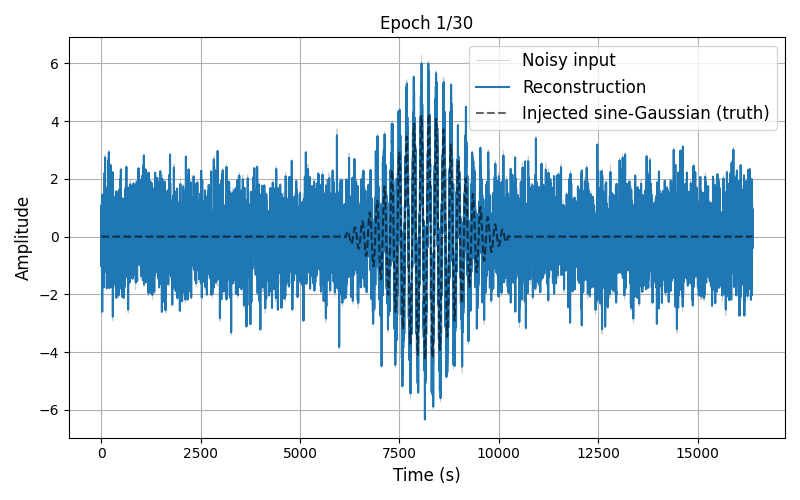

In [46]:
import matplotlib.animation as animation
from IPython.display import Image, display

t_axis_gif = np.arange(LENGTH) * DT

fig_gif, ax_gif = plt.subplots(figsize=(8, 5))
ax_gif.plot(t_axis_gif, _gif_noisy, color="gray", lw=0.6, alpha=0.4, label="Noisy input")
recon_line, = ax_gif.plot(t_axis_gif, _gif_frames[0], color="C0", lw=1.5, label="Reconstruction")
ax_gif.plot(t_axis_gif, _gif_inj, color="black", lw=1.5, ls="--", alpha=0.6, label="Injected sine-Gaussian (truth)")
ax_gif.set_xlabel("Time (s)", fontsize=12)
ax_gif.set_ylabel("Amplitude", fontsize=12)
ax_gif.legend(fontsize=12, loc="upper right")
ax_gif.grid(True)
title = ax_gif.set_title(f"Epoch 1/{len(_gif_frames)}")
plt.tight_layout()


def _update(frame_idx):
    recon_line.set_ydata(_gif_frames[frame_idx])
    title.set_text(f"Epoch {frame_idx + 1}/{len(_gif_frames)}")
    return recon_line, title


gif_ani = animation.FuncAnimation(fig_gif, _update, frames=len(_gif_frames), interval=200, blit=False)
gif_ani.save("training_progress.gif", writer="pillow", fps=5)
plt.close(fig_gif)

display(Image(filename="training_progress.gif"))

## Step 5 — Plot losses

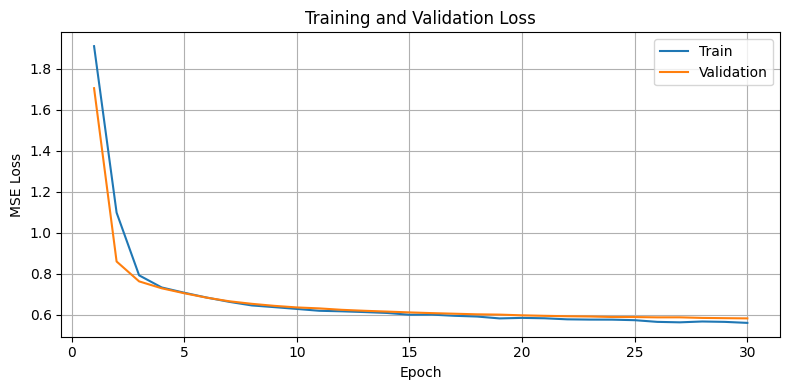

In [47]:
epochs_ran = range(1, len(train_losses) + 1)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(epochs_ran, train_losses, label="Train",      color="C0")
ax.plot(epochs_ran, val_losses,   label="Validation", color="C1")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.set_title("Training and Validation Loss")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()


## Step 6 — Test on sine-Gaussian injections

We generate fresh test examples — PyCBC (numpy) noise with a sine-Gaussian injected at a range of SNRs —
and run them through the trained model.
The model was never trained on these specific examples.
We use three different test examples at three different SNRs, reporting the SNR and mismatch ($\mathcal{M}$) above each plot. 
Intuitively, the model better recovers louder glitches than quieter ones. 
The reconstructions below feature high-frequency artifacts as the model training did not fully converge, and it is a reduced architecture compared to the published version. 
Improved performance can be achieved by training this model until convergence or by modifying the layers of DeepExtractor's U-Net to the published architecture, and increasing the resolution of the STFT spectrograms (please see above).

In [48]:
# reconstruct() is defined in Step 3 above (right after building the model) so
# Step 4's training loop can call it each epoch for the training-progress GIF.


Generating noise...
Generating noise...
Generating noise...


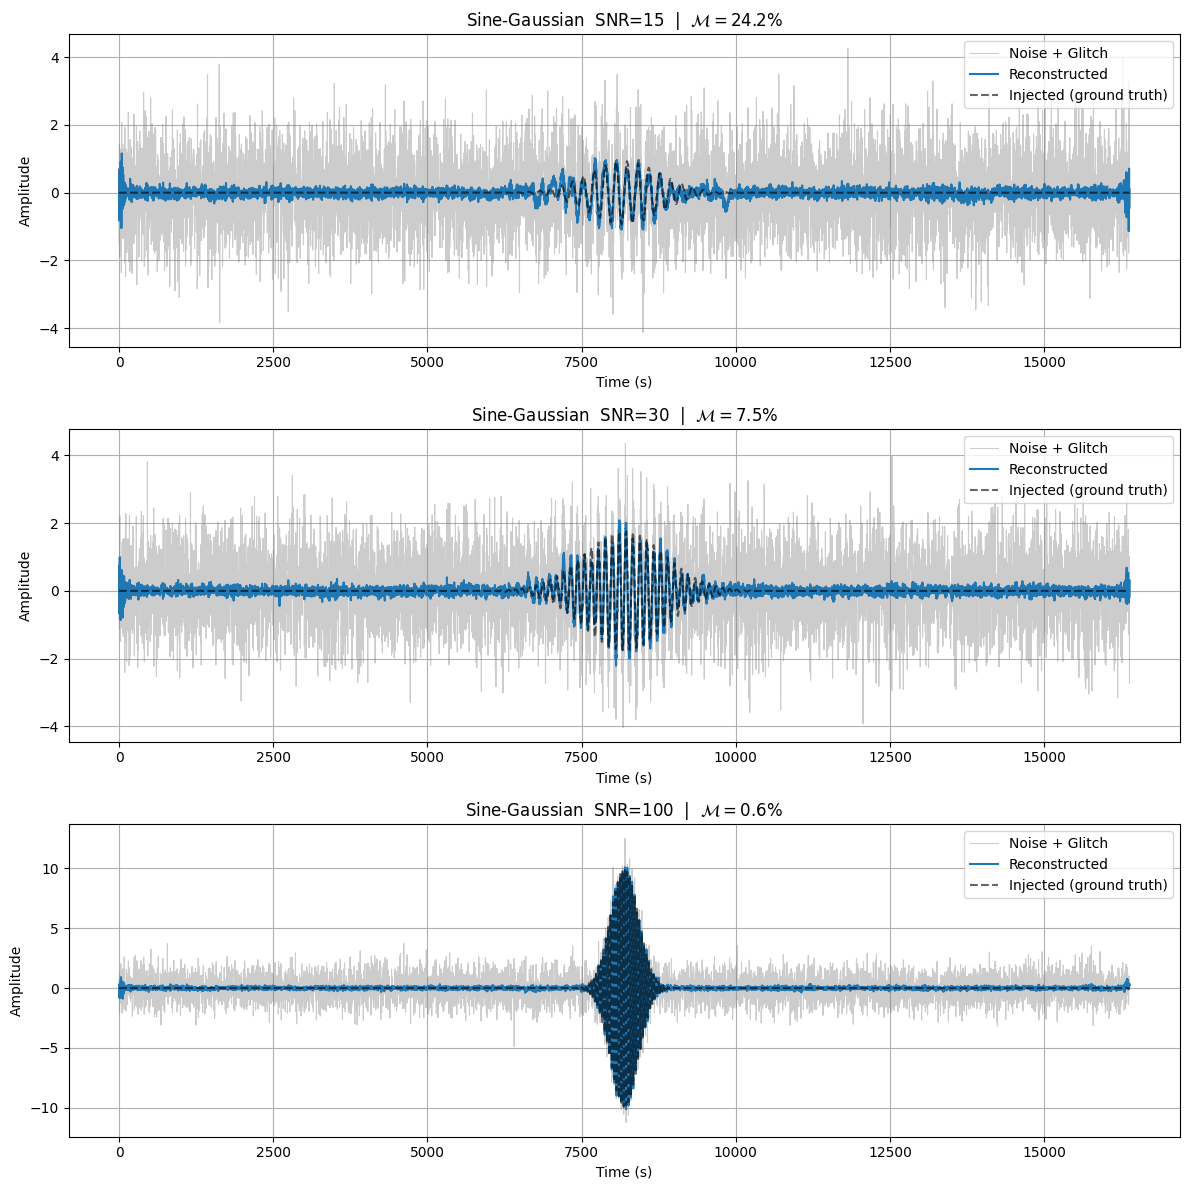

In [49]:
T_INJ = T / 2
SNR_VALUES = [15, 30, 100]

def overlap(a, b):
    """Normalised time-domain overlap (match) between two real signals.
    Equivalent to the PyCBC match on whitened data (flat PSD)."""
    return np.dot(a, b) / np.sqrt(np.dot(a, a) * np.dot(b, b))

fig, axes = plt.subplots(len(SNR_VALUES), 1, figsize=(12, 4 * len(SNR_VALUES)))
t_axis = np.arange(LENGTH) * DT

for ax, snr in zip(axes, SNR_VALUES):
    noise = generate_gaussian_noise(mean, std_dev, 1, (LENGTH,), bilby_noise=False)[0]
    
    # We set freq_max=256 when generating the sine-Gaussians for visualization purposes. This can be increased to the Nyquist frequency (i.e. freq_max=2048).
    _, wavelet = generate_sine_gaussian(duration=0.5, freq_max=256)
    wavelet = wavelet - np.mean(wavelet)
    wavelet = whitened_snr_scaling(wavelet, snr=snr)

    len_glitch = len(wavelet)
    id_start   = int(T_INJ * SAMPLE_RATE) - len_glitch // 2
    noisy      = noise.copy()
    noisy[id_start : id_start + len_glitch] += wavelet

    injected = np.zeros(LENGTH)
    injected[id_start : id_start + len_glitch] = wavelet

    reconstructed = reconstruct(noisy, model, scaler, DEVICE, N_FFT, HOP_LENGTH, WIN_LENGTH)

    match    = overlap(injected, reconstructed)
    mismatch = 1.0 - match

    ax.plot(t_axis, noisy,         color="gray",  lw=0.8, alpha=0.4, label="Noise + Glitch")
    ax.plot(t_axis, reconstructed, color="C0",    lw=1.5, label="Reconstructed")
    ax.plot(t_axis, injected,      color="black", lw=1.5, alpha=0.6, linestyle="--", label="Injected (ground truth)")
    ax.set_title(
        f"Sine-Gaussian  SNR={snr}  |  "
        f"$\\mathcal{{M}} = {mismatch*100:.1f} \% $"
    )
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Amplitude")
    ax.legend(loc="upper right")
    ax.grid(True)

plt.tight_layout()
plt.show()


---

# Part II — Hackathon Tasks

The tutorial above trained a baseline DeepExtractor (STFT U-Net) on synthetic data.
Now try four targeted experiments — each changes **one** aspect of the pipeline.
All tasks share the **same fixed test set** (generated below) so results are comparable.

| Task | What you change | Key question |
|------|----------------|-------------|
| 1 | Number of U-Net encoder levels | How does model depth affect quality? |
| 2 | Model domain: STFT → 1-D time-domain | Does operating on raw waveforms help? |
| 3 | Training-set size `N_TRAIN` | How much data do we really need? |
| 4 | Synthetic training signal types | Does a diverse training set generalise better? |

> **LISA / Mojito note** — This tutorial runs at `SAMPLE_RATE = 4096 Hz, T = 2 s, LENGTH = 8192`.
> The [Mojito LISA dataset](https://mojito-e66317.io.esa.int/) uses `dt = 2.0 s` (0.5 Hz) with
> 1000-sample windows. For LISA-compatible parameters set `SAMPLE_RATE = 0.5` and `T = 16384.0`
> in the Configuration cell, re-run from the top, and adjust signal durations/frequencies
> (e.g. duration range 20–8000 s, `freq_max = SAMPLE_RATE / 2 = 0.25` Hz).

In [50]:
# --- gengli (installed at the top of this notebook) — used for out-of-sample
# blip testing in Task 4 ------------------------------------------------------
try:
    import gengli
    GENGLI_AVAILABLE = True
    print("gengli available.")
except ImportError:
    GENGLI_AVAILABLE = False
    print("gengli not available — blip test in Task 4 will be skipped.")

# --- Fixed test set (sine-Gaussian injections, SNR drawn uniformly from a range) --
# Seeded once; do NOT re-run this cell mid-session to keep comparisons fair.
import random as _random
_random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

_N_TEST                       = 100
_SNR_MIN_TEST, _SNR_MAX_TEST  = 10, 100
_T_INJ_TEST                   = T / 2

_noisy_buf, _inj_buf, _snr_buf = [], [], []
for _ in range(_N_TEST):
    _snr = np.random.uniform(_SNR_MIN_TEST, _SNR_MAX_TEST)
    _n   = generate_gaussian_noise(mean, std_dev, 1, (LENGTH,), bilby_noise=False)[0]
    _, _w = generate_sine_gaussian(duration=0.5, freq_max=256)
    _w   = _w - np.mean(_w)
    _w   = whitened_snr_scaling(_w, snr=_snr)
    _L   = len(_w)
    _i0  = int(_T_INJ_TEST * SAMPLE_RATE) - _L // 2
    _nn  = _n.copy()
    _nn[_i0:_i0 + _L] += _w
    _ij  = np.zeros(LENGTH)
    _ij[_i0:_i0 + _L] = _w
    _noisy_buf.append(_nn)
    _inj_buf.append(_ij)
    _snr_buf.append(_snr)

TEST_NOISY    = np.array(_noisy_buf)    # (100, LENGTH)
TEST_INJECTED = np.array(_inj_buf)      # (100, LENGTH)
TEST_SNRS     = np.array(_snr_buf)
print(f"Fixed test set ready: {len(TEST_NOISY)} examples, "
     f"SNR range = [{_SNR_MIN_TEST}, {_SNR_MAX_TEST}]")

2026-07-29 13:29:56,008	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


gengli available.
Generating noise...
Generating noise...
Generating noise...
Generating noise...
Generating noise...
Generating noise...
Generating noise...
Generating noise...
Generating noise...
Generating noise...
Generating noise...
Generating noise...
Generating noise...
Generating noise...
Generating noise...
Generating noise...
Generating noise...
Generating noise...
Generating noise...
Generating noise...
Generating noise...
Generating noise...
Generating noise...
Generating noise...
Generating noise...
Generating noise...
Generating noise...
Generating noise...
Generating noise...
Generating noise...
Generating noise...
Generating noise...
Generating noise...
Generating noise...
Generating noise...
Generating noise...
Generating noise...
Generating noise...
Generating noise...
Generating noise...
Generating noise...
Generating noise...
Generating noise...
Generating noise...
Generating noise...
Generating noise...
Generating noise...
Generating noise...
Generating noise...
Ge

In [51]:
# --- Shared helpers used by all four tasks ------------------------------------
EPOCHS_TASK = 20   #  This is a quite a small number of epochs to achieve good performance; 
                    # increase to 50-100 for better results. Early stopping will prevent overfitting if you do so.


def _train_stft(mdl, tr_ld, vl_ld, epochs=EPOCHS_TASK):
    # Train an STFT model (or any model whose loader yields 2-D spectrograms).
    _lfn = nn.MSELoss()
    _opt = optim.Adam(mdl.parameters(), lr=LR)
    _sch = ReduceLROnPlateau(_opt, mode="min", factor=LR_FACTOR, patience=LR_PATIENCE)
    _amp = torch.amp.GradScaler("cuda") if DEVICE == "cuda" else torch.amp.GradScaler("cpu", enabled=False)
    tr_ls, vl_ls = [], []
    best_v, es_c = float("inf"), 0
    for ep in range(epochs):
        tl = train_fn(tr_ld, mdl, _opt, _lfn, _amp, DEVICE)
        vl = check_accuracy(vl_ld, mdl, device=DEVICE)
        tr_ls.append(tl)
        vl_ls.append(vl)
        _sch.step(vl)
        print(f"  ep {ep+1:>2}/{epochs}  train={tl:.5f}  val={vl:.5f}")
        if vl < best_v:
            best_v = vl
            es_c   = 0
        else:
            es_c += 1
            if es_c >= EARLY_STOPPING_PATIENCE:
                print(f"  Early stopping at epoch {ep+1}.")
                break
    return tr_ls, vl_ls


def _mismatch_stft(mdl, scl=None):
    # Mean mismatch of an STFT model on the fixed test set.
    if scl is None:
        scl = scaler
    mm = [
        1.0 - overlap(inj, reconstruct(noisy, mdl, scl, DEVICE, N_FFT, HOP_LENGTH, WIN_LENGTH))
        for noisy, inj in zip(TEST_NOISY, TEST_INJECTED)
    ]
    return float(np.mean(mm))


def _mismatch_1d(mdl, scl=None):
    # Mean mismatch of a 1-D time-domain model on the fixed test set.
    if scl is None:
        scl = scaler
    mdl.eval()
    mm = []
    with torch.no_grad():
        for noisy, inj in zip(TEST_NOISY, TEST_INJECTED):
            sc_in  = scl.transform(noisy.reshape(-1, 1)).reshape(1, 1, -1)
            inp    = torch.tensor(sc_in, dtype=torch.float32).to(DEVICE)
            out    = mdl(inp).cpu().numpy().squeeze()
            bg_raw = scl.inverse_transform(out.reshape(-1, 1)).reshape(-1)
            mm.append(1.0 - overlap(inj, noisy - bg_raw))
    mdl.train()
    return float(np.mean(mm))


def _plot_val_curves(loss_dict, title="Validation Loss"):
    fig, ax = plt.subplots(figsize=(8, 4))
    for j, (lbl, (_, vl)) in enumerate(loss_dict.items()):
        # First curve stays fully opaque; later ones are dimmed so anything
        # plotted underneath (e.g. Model A vs. Model B) stays visible.
        ax.plot(range(1, len(vl) + 1), vl, label=lbl, alpha=1.0 if j == 0 else 0.6)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MSE Loss")
    ax.set_title(title)
    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    plt.show()

## Task 1 — Effect of Model Depth

The baseline model uses `features = [32, 64, 128, 256]` (4 encoder levels).
Shallower models train faster but may lack capacity; deeper ones risk overfitting on small datasets.

**TODO:** Run the comparison below as-is, then add a 5th level (`[..., 512]`) or strip
it back to a single level and observe how the validation loss and test mismatch change.

*Discussion questions:*
- At what depth does adding more layers stop helping?
- Do you see signs of overfitting (val loss rising while train loss falls)?


────────────────────────────────────────────────────────────
Training: 2-layer [32,64]  (466,914 params)


Training on batch: 100%|██████████| 32/32 [00:08<00:00,  3.64it/s, loss=1.56]


Validation Loss: 1.825452
  ep  1/20  train=1.95913  val=1.82545


Training on batch: 100%|██████████| 32/32 [00:09<00:00,  3.50it/s, loss=1.1] 


Validation Loss: 1.169138
  ep  2/20  train=1.30471  val=1.16914


...

Validation Loss: 0.616138
  ep 18/20  train=0.60853  val=0.61614


Training on batch: 100%|██████████| 32/32 [00:14<00:00,  2.17it/s, loss=0.666]


Validation Loss: 0.609197
  ep 19/20  train=0.60380  val=0.60920


Training on batch: 100%|██████████| 32/32 [00:14<00:00,  2.23it/s, loss=0.579]


Validation Loss: 0.601566
  ep 20/20  train=0.59318  val=0.60157
  Mean test mismatch: 12.07 %


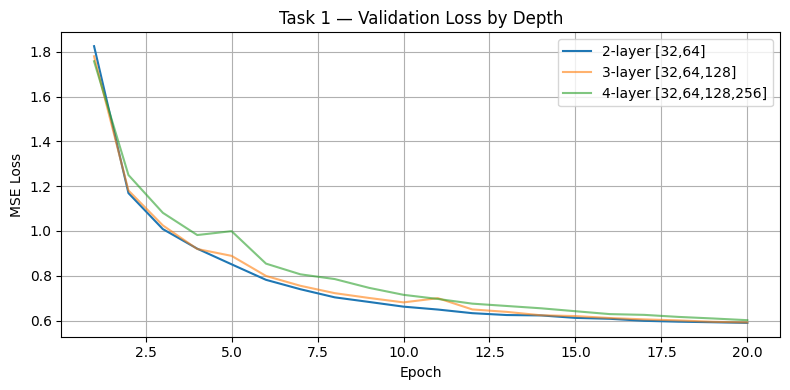

In [52]:
# --- Task 1: compare U-Net depths --------------------------------------------
# TODO: add or remove entries in features_configs to explore other depths
features_configs = {
    "2-layer [32,64]":           [32, 64],
    "3-layer [32,64,128]":       [32, 64, 128],
    "4-layer [32,64,128,256]":   [32, 64, 128, 256],   # matches baseline above
}

task1_curves    = {}   # label -> (train_losses, val_losses)
task1_mismatch  = {}   # label -> mean mismatch on TEST_NOISY

for lbl, feats in features_configs.items():
    print(f"\n{'─'*60}")
    print(f"Training: {lbl}  ({sum(p.numel() for p in UNET2D(2,2,feats).parameters()):,} params)")
    mdl = UNET2D(in_channels=2, out_channels=2, features=feats, dropout_p=0.0).to(DEVICE)
    tr_ls, vl_ls     = _train_stft(mdl, train_loader, val_loader)
    task1_curves[lbl]   = (tr_ls, vl_ls)
    task1_mismatch[lbl] = _mismatch_stft(mdl)
    print(f"  Mean test mismatch: {task1_mismatch[lbl]*100:.2f} %")

_plot_val_curves(task1_curves, title="Task 1 — Validation Loss by Depth")

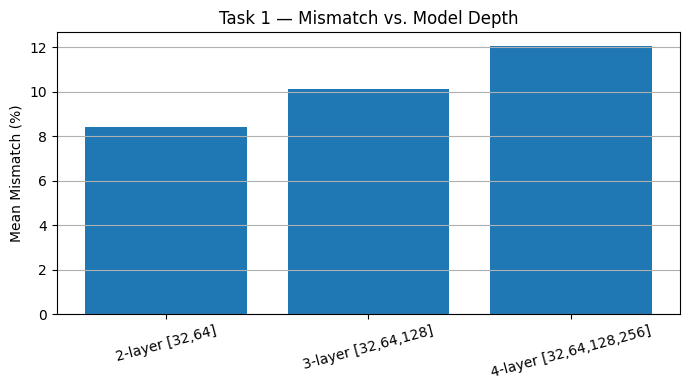

  2-layer [32,64]: 8.40 %
  3-layer [32,64,128]: 10.12 %
  4-layer [32,64,128,256]: 12.07 %


In [53]:
# Task 1 summary bar chart
fig, ax = plt.subplots(figsize=(7, 4))
lbls = list(task1_mismatch.keys())
vals = [task1_mismatch[l] * 100 for l in lbls]
ax.bar(lbls, vals, color="C0")
ax.set_ylabel("Mean Mismatch (%)")
ax.set_title("Task 1 — Mismatch vs. Model Depth")
ax.tick_params(axis="x", labelrotation=15)
ax.grid(axis="y")
plt.tight_layout()
plt.show()
for l, v in zip(lbls, vals):
    print(f"  {l}: {v:.2f} %")

## Task 2 — Time-Domain vs. STFT Model

DeepExtractor normally operates on **STFT spectrograms** (magnitude + phase, shape `(2, 129, 129)`).
`UNET1D` instead processes the **raw 1-D waveform** directly — no frequency transform.

| | Input shape | Ops | Params (same depth) |
|--|------------|-----|---------------------|
| `UNET2D` (STFT) | `(B, 2, 129, 129)` | 2-D convolutions | ~7 M |
| `UNET1D` (TD) | `(B, 1, 8192)` | 1-D convolutions | ~3 M |

**TODO:** Run the cells below to train the 1-D model, then compare its mismatch against
the STFT baseline.

*Discussion questions:*
- Which model achieves lower mismatch?
- Is the time-domain model faster or slower to train per epoch?


In [54]:
# --- Task 2: 1-D DataLoaders (reuse already-scaled arrays) -------------------
class DoubleConv1D(nn.Module):
    def __init__(self, in_channels, out_channels, dropout_p=0.0):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv1d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(inplace=True),
        )
        # Same MC-Dropout pattern as DoubleConv2D above: Dropout1d has no
        # weights/buffers, so dropout_p=0.0 checkpoints stay fully compatible.
        self.dropout = nn.Dropout1d(dropout_p) if dropout_p > 0.0 else None

    def forward(self, x):
        x = self.conv(x)
        if self.dropout is not None:
            x = self.dropout(x)
        return x


class UNET1D(nn.Module):
    """Same architecture as UNET2D (Step 3) but with 1-D convolutions, operating
    directly on the raw waveform instead of a spectrogram. dropout_p works the
    same way as UNET2D — off by default, decoder + bottleneck only."""
    def __init__(self, in_channels=1, out_channels=1, features=[64, 128, 256, 512],
                 dropout_p=0.0):
        super().__init__()
        self.ups = nn.ModuleList()
        self.downs = nn.ModuleList()
        self.pool = nn.MaxPool1d(kernel_size=2, stride=2)

        for feature in features:
            self.downs.append(DoubleConv1D(in_channels, feature, dropout_p=0.0))
            in_channels = feature

        for feature in reversed(features):
            self.ups.append(nn.ConvTranspose1d(feature * 2, feature, kernel_size=2, stride=2))
            self.ups.append(DoubleConv1D(feature * 2, feature, dropout_p=dropout_p))

        self.bottleneck = DoubleConv1D(features[-1], features[-1] * 2, dropout_p=dropout_p)
        self.final_conv = nn.Conv1d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        skip_connections = []
        for down in self.downs:
            x = down(x)
            skip_connections.append(x)
            x = self.pool(x)

        x = self.bottleneck(x)
        skip_connections = skip_connections[::-1]

        for idx in range(0, len(self.ups), 2):
            x = self.ups[idx](x)
            skip_connection = skip_connections[idx // 2]
            if x.shape != skip_connection.shape:
                x = F.interpolate(x, size=skip_connection.shape[2:])
            concat_skip = torch.cat((skip_connection, x), dim=1)
            x = self.ups[idx + 1](concat_skip)

        return self.final_conv(x)


# Add a channel dimension: (N, LENGTH) -> (N, 1, LENGTH)
x_tr_1d = torch.tensor(glitch_train_scaled, dtype=torch.float32).unsqueeze(1)
y_tr_1d = torch.tensor(bg_train_scaled,     dtype=torch.float32).unsqueeze(1)
x_vl_1d = torch.tensor(glitch_val_scaled,   dtype=torch.float32).unsqueeze(1)
y_vl_1d = torch.tensor(bg_val_scaled,       dtype=torch.float32).unsqueeze(1)

train_ds_1d     = TensorDataset(x_tr_1d, y_tr_1d)
val_ds_1d       = TensorDataset(x_vl_1d, y_vl_1d)
train_loader_1d = DataLoader(train_ds_1d, batch_size=BATCH_SIZE, shuffle=True)
val_loader_1d   = DataLoader(val_ds_1d,   batch_size=BATCH_SIZE, shuffle=False)
print(f"1-D input shape: {x_tr_1d.shape}")

1-D input shape: torch.Size([1000, 1, 8192])


In [ ]:
# --- Task 2: train UNET1D and compare with STFT baseline --------------------
model_1d = UNET1D(in_channels=1, out_channels=1, features=[32, 64, 128, 256],
                  dropout_p=DROPOUT_P).to(DEVICE)
print(f"UNET1D parameters: {sum(p.numel() for p in model_1d.parameters()):,}")

print("\nTraining UNET1D (time-domain)...")
trl_1d, vll_1d = _train_stft(model_1d, train_loader_1d, val_loader_1d)
mm_1d = _mismatch_1d(model_1d)
print(f"\nUNET1D  mean test mismatch : {mm_1d*100:.2f} %")

# Retrieve STFT result from Task 1 (4-layer) or re-evaluate the baseline
_stft_lbl = "4-layer [32,64,128,256]"
mm_stft   = task1_mismatch.get(_stft_lbl, _mismatch_stft(model))
print(f"UNET2D  mean test mismatch : {mm_stft*100:.2f} %")

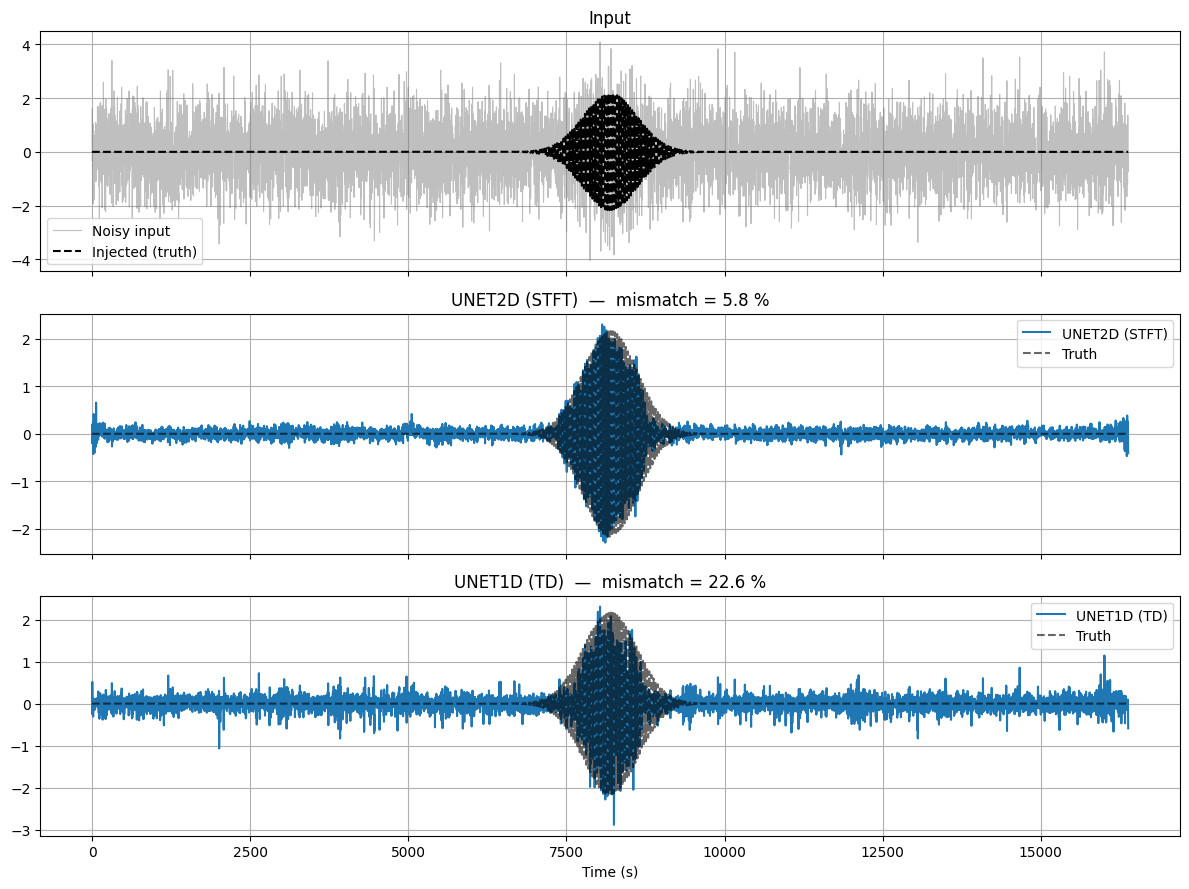

In [ ]:
# Task 2: side-by-side reconstruction at SNR=30 for one test example
_idx    = int(np.argmin(np.abs(TEST_SNRS - 30)))  # closest test example to SNR=30
_noisy  = TEST_NOISY[_idx]
_inj    = TEST_INJECTED[_idx]
t_axis  = np.arange(LENGTH) * DT

_r_stft = reconstruct(_noisy, model, scaler, DEVICE, N_FFT, HOP_LENGTH, WIN_LENGTH)

model_1d.eval()
with torch.no_grad():
    _sc  = scaler.transform(_noisy.reshape(-1, 1)).reshape(1, 1, -1)
    _out = model_1d(torch.tensor(_sc, dtype=torch.float32).to(DEVICE)).cpu().numpy().squeeze()
    _bg  = scaler.inverse_transform(_out.reshape(-1, 1)).reshape(-1)
_r_1d = _noisy - _bg

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

axes[0].plot(t_axis, _noisy, color="gray", lw=0.8, alpha=0.5, label="Noisy input")
axes[0].plot(t_axis, _inj,  color="black", lw=1.5, ls="--", label="Injected (truth)")
axes[0].set_title("Input")
axes[0].legend(); axes[0].grid(True)

for ax, recon, lbl in [(axes[1], _r_stft, "UNET2D (STFT)"),
                       (axes[2], _r_1d,   "UNET1D (TD)")]:
    mm = 1.0 - overlap(_inj, recon)
    ax.plot(t_axis, recon, lw=1.5, label=lbl)
    ax.plot(t_axis, _inj, color="black", lw=1.5, ls="--", alpha=0.6, label="Truth")
    ax.set_title(f"{lbl}  —  mismatch = {mm*100:.1f} %")
    ax.legend(); ax.grid(True)

axes[-1].set_xlabel("Time (s)")
plt.tight_layout()
plt.show()

## Task 3 — Effect of Dataset Size

More training data usually improves generalisation — but generating (or labelling) data has a cost.
Here you train the same model architecture on datasets of increasing size and measure how
reconstruction quality on the **fixed test set** changes.

**TODO:** Run the cell below, then add larger values like `2000` or `5000` to
`n_train_values`.

*Discussion questions:*
- Is there a "knee" in the mismatch-vs-N curve after which more data stops helping?
- What does this imply about how much real detector data you would need?


────────────────────────────────────────────────────────────
N_TRAIN = 200
Generating noise...
Generating noise...


Generating Synthetic Train Data:   0%|          | 0/200 [00:00<?, ?it/s]/var/folders/gv/z_2s63x116vbz6s2hmnl7mkc0000gn/T/ipykernel_12447/3946450841.py:32: RuntimeWarning: divide by zero encountered in divide
  glitch = (glitch.T * snr / np.sqrt(true_sigma_sq)).T
Training on batch: 100%|██████████| 7/7 [00:03<00:00,  2.31it/s, loss=2.39]


Validation Loss: 2.383543
  ep  1/50  train=2.48751  val=2.38354


Training on batch: 100%|██████████| 7/7 [00:03<00:00,  2.16it/s, loss=2.19]


Validation Loss: 2.363073
  ep  2/50  train=2.27487  val=2.36307


...

Validation Loss: 0.535263
  ep 48/50  train=0.57613  val=0.53526


Training on batch: 100%|██████████| 32/32 [00:13<00:00,  2.31it/s, loss=0.542]


Validation Loss: 0.535605
  ep 49/50  train=0.57177  val=0.53560


Training on batch: 100%|██████████| 32/32 [00:16<00:00,  1.96it/s, loss=0.576]


Validation Loss: 0.532932
  ep 50/50  train=0.57098  val=0.53293
  Mean test mismatch: 9.46 %


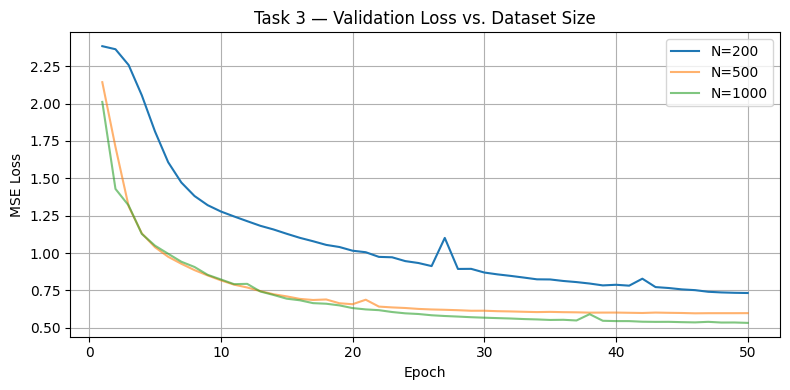

In [ ]:
# --- Task 3: vary training-set size ------------------------------------------
# TODO: add more values (e.g. 2000, 5000) to see the full curve
n_train_values = [200, 500, 1000]

task3_curves   = {}
task3_mismatch = {}

for n_tr in n_train_values:
    print(f"\n{'─'*60}\nN_TRAIN = {n_tr}")

    _tr_noise = generate_gaussian_noise(mean, std_dev, n_tr,  (LENGTH,), bilby_noise=False)
    _vl_noise = generate_gaussian_noise(mean, std_dev, N_VAL, (LENGTH,), bilby_noise=False)
    _gl_tr, _bg_tr = generate_synthetic_data(_tr_noise, bilby_noise=False, phase="train")
    _gl_vl, _bg_vl = generate_synthetic_data(_vl_noise, bilby_noise=False, phase="val")

    _sc_gl_tr  = scaler.transform(_gl_tr.reshape(-1, 1)).reshape(_gl_tr.shape)
    _sc_bg_tr  = scaler.transform(_bg_tr.reshape(-1, 1)).reshape(_bg_tr.shape)
    _sc_gl_vl  = scaler.transform(_gl_vl.reshape(-1, 1)).reshape(_gl_vl.shape)
    _sc_bg_vl  = scaler.transform(_bg_vl.reshape(-1, 1)).reshape(_bg_vl.shape)

    _sp_gl_tr  = to_mag_phase(_sc_gl_tr)
    _sp_bg_tr  = to_mag_phase(_sc_bg_tr)
    _sp_gl_vl  = to_mag_phase(_sc_gl_vl)
    _sp_bg_vl  = to_mag_phase(_sc_bg_vl)

    _ld_tr = DataLoader(TensorDataset(_sp_gl_tr, _sp_bg_tr), batch_size=BATCH_SIZE, shuffle=True)
    _ld_vl = DataLoader(TensorDataset(_sp_gl_vl, _sp_bg_vl), batch_size=BATCH_SIZE, shuffle=False)

    _mdl = UNET2D(in_channels=2, out_channels=2, features=[32, 64, 128, 256],
                 dropout_p=DROPOUT_P).to(DEVICE)
    tr_ls, vl_ls           = _train_stft(_mdl, _ld_tr, _ld_vl)
    task3_curves[f"N={n_tr}"]   = (tr_ls, vl_ls)
    task3_mismatch[f"N={n_tr}"] = _mismatch_stft(_mdl)
    print(f"  Mean test mismatch: {task3_mismatch[f'N={n_tr}']*100:.2f} %")

_plot_val_curves(task3_curves, title="Task 3 — Validation Loss vs. Dataset Size")

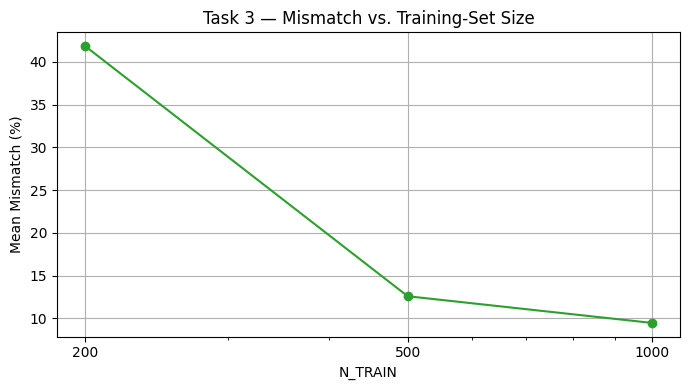

In [ ]:
# Task 3 summary: mismatch as a function of N_TRAIN
ns   = [int(k.split("=")[1]) for k in task3_mismatch]
mms  = [task3_mismatch[k] * 100 for k in task3_mismatch]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(ns, mms, "o-", color="C2")
ax.set_xlabel("N_TRAIN")
ax.set_ylabel("Mean Mismatch (%)")
ax.set_title("Task 3 — Mismatch vs. Training-Set Size")
ax.set_xscale("log")
ax.set_xticks(ns)
ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
ax.xaxis.set_minor_formatter(mticker.NullFormatter())  # suppress log-scale sci-notation minor ticks
ax.grid(True)
plt.tight_layout()
plt.show()

## Task 4 — Basis Functions & Out-of-Sample Generalisation

The default training set mixes all five synthetic signal types
(chirps, sines, sine-Gaussians, Gaussian pulses, ringdowns).
What happens if the model sees only **one** type during training?

You will train two models, one with only sine-gaussians and the other with all 5 training classes, and compare them on:
1. **In-sample** — the fixed sine-Gaussian test set above
2. **Out-of-sample (ringdowns)** — synthetic ringdown glitches (no extra install)
3. **Out-of-sample (gengli blips)** *(optional, if gengli is installed)* — a proxy for
   real LIGO detector transients; treated here as raw sample arrays at whatever rate
   you are training at (the "dimensionality convention" rather than a physical resample)

**TODO:** Run as-is, then try changing `SIGNAL_TYPES_B` to other combinations
(e.g. only chirps + ringdowns) and see which mix generalises best to blip glitches.

*Discussion questions:*
- Which model performs better in-sample? Out-of-sample?
- Is a diverse training set always better?

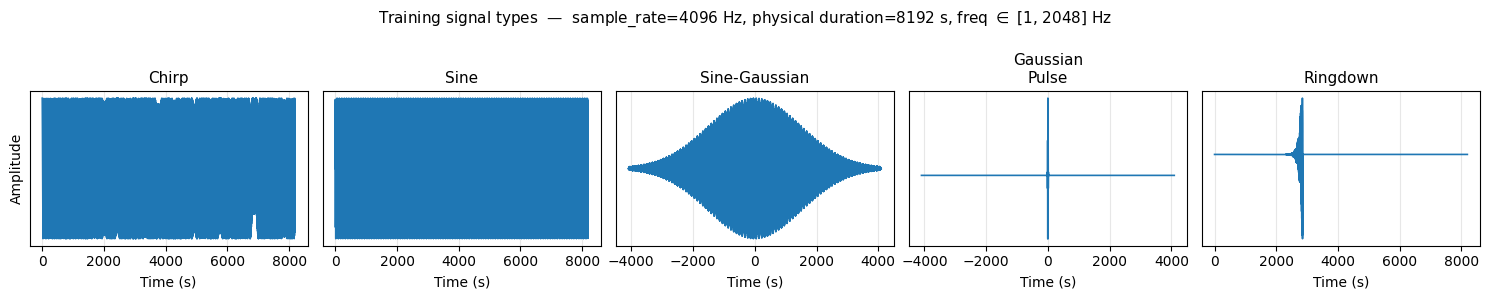

In [ ]:
# --- Task 4: basis waveform gallery -----------------------------------------
# Each signal generated at the training sample rate with explicit parameters.
# (reuses the generators defined in Step 1 above)
np.random.seed(7)
_NYQUIST  = SAMPLE_RATE // 2   # 2048 Hz
_DURATION = 1.0                # seconds at SAMPLE_RATE; physical duration = _DURATION * SAMPLE_RATE * DT

_t_ch, _s_ch = generate_chirp(
    _DURATION, sample_rate=SAMPLE_RATE, f0_min=1, f0_max=_NYQUIST, f1_min=1, f1_max=_NYQUIST)
_t_si, _s_si = generate_sine(
    _DURATION, sample_rate=SAMPLE_RATE, freq_min=1, freq_max=_NYQUIST)
_t_sg, _s_sg = generate_sine_gaussian(
    _DURATION, sample_rate=SAMPLE_RATE, freq_min=1, freq_max=_NYQUIST)
_t_gp, _s_gp = generate_gaussian_pulse(
    _DURATION, sample_rate=SAMPLE_RATE, fc_min=1, fc_max=_NYQUIST)
_t_rd, _s_rd = ringdown(
    _DURATION, sample_rate=SAMPLE_RATE)   # freq drawn internally from [10, NYQUIST]

_gallery = [
    (_t_ch, _s_ch, "Chirp"),
    (_t_si, _s_si, "Sine"),
    (_t_sg, _s_sg, "Sine-Gaussian"),
    (_t_gp, _s_gp, "Gaussian\nPulse"),
    (_t_rd, _s_rd, "Ringdown"),
]

_phys_dur = _DURATION * SAMPLE_RATE * DT  # physical duration in seconds

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for ax, (t, sig, name) in zip(axes, _gallery):
    ax.plot(t * SAMPLE_RATE * DT, sig, lw=1.2, color="C0")
    ax.set_title(name, fontsize=11)
    ax.set_xlabel("Time (s)")
    ax.set_yticks([])
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Amplitude")
fig.suptitle(
    f"Training signal types  —  sample_rate={SAMPLE_RATE} Hz, "
    f"physical duration={_phys_dur:.0f} s, freq $\\in$ [1, {_NYQUIST}] Hz",
    fontsize=11,
)
plt.tight_layout()
plt.show()


In [ ]:
# --- Task 4: custom data generator with selectable signal types ---------------
# SNR_MIN/SNR_MAX and the generator functions are already defined in Step 1 above.

_gen_chirp = generate_chirp
_gen_sine = generate_sine
_gen_sg4 = generate_sine_gaussian
_gen_gp = generate_gaussian_pulse
_gen_rd = ringdown

_FN4 = {
    "chirp":          _gen_chirp,
    "sine":           _gen_sine,
    "sine_gaussian":  _gen_sg4,
    "gaussian_pulse": _gen_gp,
    "ringdown":       _gen_rd,
}
_T_INJ4 = T / 2


def _gen_typed(noise_arr, sig_types, label=""):
    glitches, bgs = [], []
    for bg in tqdm(noise_arr, desc=f"Generating {label}"):
        noisy = bg.copy()
        for _ in range(np.random.randint(1, 30)):
            s_type   = random.choice(sig_types)
            duration = np.random.uniform(0.125, T)
            _, sig   = _FN4[s_type](duration)
            if len(sig) == 0 or np.isnan(sig).any():
                continue
            sig  = sig - np.mean(sig)
            sig  = whitened_snr_scaling(sig, snr=np.random.uniform(SNR_MIN, SNR_MAX))
            L    = len(sig)
            id0  = int(_T_INJ4 * SAMPLE_RATE) - L // 2
            if id0 < 0 or id0 + L > LENGTH:
                continue
            hi   = max(1, LENGTH - id0 - L)
            if -id0 >= hi:
                continue
            sh   = np.random.randint(-id0, hi)
            s, e = id0 + sh, min(id0 + sh + L, LENGTH)
            noisy[s:e] += sig[:e - s]
        glitches.append(noisy)
        bgs.append(bg)
    g, b = np.array(glitches), np.array(bgs)
    ok = ~np.any(np.isnan(g) | np.isinf(g) | (np.abs(g) > np.finfo(np.float64).max), axis=1)
    return g[ok], b[ok]


def _spec_loaders(gl, bg, gl_vl, bg_vl):
    def _spec(a):
        sc = scaler.transform(a.reshape(-1, 1)).reshape(a.shape)
        return to_mag_phase(sc)
    ld_tr = DataLoader(TensorDataset(_spec(gl),    _spec(bg)),    batch_size=BATCH_SIZE, shuffle=True)
    ld_vl = DataLoader(TensorDataset(_spec(gl_vl), _spec(bg_vl)), batch_size=BATCH_SIZE, shuffle=False)
    return ld_tr, ld_vl


# TODO: change SIGNAL_TYPES_B to try different training mixes
SIGNAL_TYPES_A = ["sine_gaussian"]
SIGNAL_TYPES_B = ["chirp", "sine", "sine_gaussian", "gaussian_pulse", "ringdown"]

_t4_tr_noise = generate_gaussian_noise(mean, std_dev, N_TRAIN, (LENGTH,), bilby_noise=False)
_t4_vl_noise = generate_gaussian_noise(mean, std_dev, N_VAL,   (LENGTH,), bilby_noise=False)

print(f"Model A: {SIGNAL_TYPES_A}")
_gl_A,  _bg_A  = _gen_typed(_t4_tr_noise.copy(), SIGNAL_TYPES_A, "Model A train")
_glv_A, _bgv_A = _gen_typed(_t4_vl_noise.copy(), SIGNAL_TYPES_A, "Model A val")

print(f"\nModel B: {SIGNAL_TYPES_B}")
_gl_B,  _bg_B  = _gen_typed(_t4_tr_noise.copy(), SIGNAL_TYPES_B, "Model B train")
_glv_B, _bgv_B = _gen_typed(_t4_vl_noise.copy(), SIGNAL_TYPES_B, "Model B val")

ld_A_tr, ld_A_vl = _spec_loaders(_gl_A,  _bg_A,  _glv_A, _bgv_A)
ld_B_tr, ld_B_vl = _spec_loaders(_gl_B,  _bg_B,  _glv_B, _bgv_B)
print("Data ready.")

Generating noise...
Generating noise...
Model A: ['sine_gaussian']


Generating Model A val: 100%|██████████| 200/200 [00:00<00:00, 403.95it/s]



Model B: ['chirp', 'sine', 'sine_gaussian', 'gaussian_pulse', 'ringdown']


Generating Model B val: 100%|██████████| 200/200 [00:00<00:00, 404.72it/s]


Data ready.


Training Model A (sine-Gaussian only)...


Training on batch: 100%|██████████| 32/32 [00:14<00:00,  2.23it/s, loss=1.67]


Validation Loss: 1.876621
  ep  1/20  train=2.08946  val=1.87662


Training on batch: 100%|██████████| 32/32 [00:13<00:00,  2.34it/s, loss=1.3] 


Validation Loss: 1.298756
  ep  2/20  train=1.47605  val=1.29876


...

Validation Loss: 0.643702
  ep 18/20  train=0.67205  val=0.64370


Training on batch: 100%|██████████| 32/32 [00:14<00:00,  2.17it/s, loss=0.619]


Validation Loss: 0.638188
  ep 19/20  train=0.66300  val=0.63819


Training on batch: 100%|██████████| 32/32 [00:14<00:00,  2.16it/s, loss=0.626]


Validation Loss: 0.631507
  ep 20/20  train=0.65328  val=0.63151


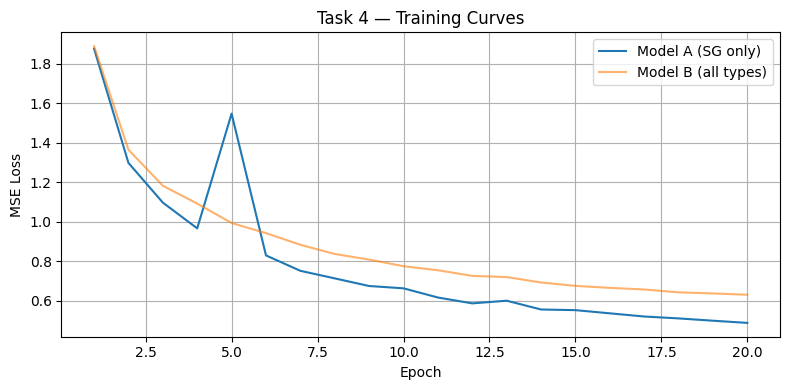

In [ ]:
# --- Task 4: train Model A and Model B ---------------------------------------
print("Training Model A (sine-Gaussian only)...")
model_A = UNET2D(in_channels=2, out_channels=2, features=[32, 64, 128, 256],
                 dropout_p=DROPOUT_P).to(DEVICE)
trl_A, vll_A = _train_stft(model_A, ld_A_tr, ld_A_vl, epochs=20) # Lower the epochs to 20 for faster training in this example

print("\nTraining Model B (all 5 types)...")
model_B = UNET2D(in_channels=2, out_channels=2, features=[32, 64, 128, 256],
                 dropout_p=DROPOUT_P).to(DEVICE)
trl_B, vll_B = _train_stft(model_B, ld_B_tr, ld_B_vl, epochs=20)

_plot_val_curves(
    {"Model A (SG only)": (trl_A, vll_A), "Model B (all types)": (trl_B, vll_B)},
    title="Task 4 — Training Curves",
)

In [ ]:
# --- Task 4: in-sample test (sine-Gaussians) ---------------------------------
mm_A_sg = _mismatch_stft(model_A)
mm_B_sg = _mismatch_stft(model_B)
print(f"In-sample (sine-Gaussians):")
print(f"  Model A: {mm_A_sg*100:.2f} %   Model B: {mm_B_sg*100:.2f} %")

# --- Out-of-sample: ringdown glitches (no extra install needed) ---------------
_oos_noise = generate_gaussian_noise(mean, std_dev, 30, (LENGTH,), bilby_noise=False)
_T_OOS = T / 2
_oos_noisy_list, _oos_inj_list = [], []
for _n in _oos_noise:
    _, _rd = _gen_rd(duration=np.random.uniform(0.125, T))
    _rd = _rd - np.mean(_rd)
    _rd = whitened_snr_scaling(_rd, snr=np.random.uniform(30, 100))
    _L  = len(_rd)
    _i0 = int(_T_OOS * SAMPLE_RATE) - _L // 2
    if _i0 < 0 or _i0 + _L > LENGTH:
        continue
    _nn = _n.copy()
    _nn[_i0:_i0 + _L] += _rd
    _ij = np.zeros(LENGTH)
    _ij[_i0:_i0 + _L] = _rd
    _oos_noisy_list.append(_nn)
    _oos_inj_list.append(_ij)
_oos_n  = np.array(_oos_noisy_list)
_oos_ij = np.array(_oos_inj_list)

mm_A_rd = float(np.mean([
    1 - overlap(ij, reconstruct(n, model_A, scaler, DEVICE, N_FFT, HOP_LENGTH, WIN_LENGTH))
    for n, ij in zip(_oos_n, _oos_ij)
]))
mm_B_rd = float(np.mean([
    1 - overlap(ij, reconstruct(n, model_B, scaler, DEVICE, N_FFT, HOP_LENGTH, WIN_LENGTH))
    for n, ij in zip(_oos_n, _oos_ij)
]))
print(f"Out-of-sample (ringdowns):")
print(f"  Model A: {mm_A_rd*100:.2f} %   Model B: {mm_B_rd*100:.2f} %")

# --- Optional: gengli blip glitches ------------------------------------------
mm_A_bl = mm_B_bl = None
if GENGLI_AVAILABLE:
    import gengli as _gengli
    _ggen   = _gengli.glitch_generator("H1")
    _bl_noisy_list, _bl_inj_list = [], []
    for _n in _oos_noise[:20]:
        _blip = np.array(_ggen.get_glitch(1, srate=4096, snr=10, alpha=0.2, fhigh=1024)).squeeze()
        _blip = _blip - np.mean(_blip)
        _blip = whitened_snr_scaling(_blip, snr=30)
        _L    = min(len(_blip), LENGTH)
        _i0   = max(0, int(_T_OOS * SAMPLE_RATE) - _L // 2)
        _i0   = min(_i0, LENGTH - _L)
        _nn   = _n.copy()
        _nn[_i0:_i0 + _L]  += _blip[:_L]
        _ij = np.zeros(LENGTH)
        _ij[_i0:_i0 + _L]   = _blip[:_L]
        _bl_noisy_list.append(_nn)
        _bl_inj_list.append(_ij)
    _bl_n  = np.array(_bl_noisy_list)
    _bl_ij = np.array(_bl_inj_list)
    mm_A_bl = float(np.mean([
        1 - overlap(ij, reconstruct(n, model_A, scaler, DEVICE, N_FFT, HOP_LENGTH, WIN_LENGTH))
        for n, ij in zip(_bl_n, _bl_ij)
    ]))
    mm_B_bl = float(np.mean([
        1 - overlap(ij, reconstruct(n, model_B, scaler, DEVICE, N_FFT, HOP_LENGTH, WIN_LENGTH))
        for n, ij in zip(_bl_n, _bl_ij)
    ]))
    print(f"Out-of-sample (gengli blips, raw samples treated as training-rate data):")
    print(f"  Model A: {mm_A_bl*100:.2f} %   Model B: {mm_B_bl*100:.2f} %")
else:
    print("(gengli not installed — blip test skipped)")

In-sample (sine-Gaussians):
  Model A: 25.00 %   Model B: 26.96 %
Generating noise...
Out-of-sample (ringdowns):
  Model A: 9.99 %   Model B: 9.96 %


/opt/homebrew/Caskroom/miniforge/base/envs/deepextractor/lib/python3.12/site-packages/gengli/glitch_generator.py:90: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  dict_weigh

Out-of-sample (gengli blips, raw samples treated as training-rate data):
  Model A: 30.23 %   Model B: 25.56 %


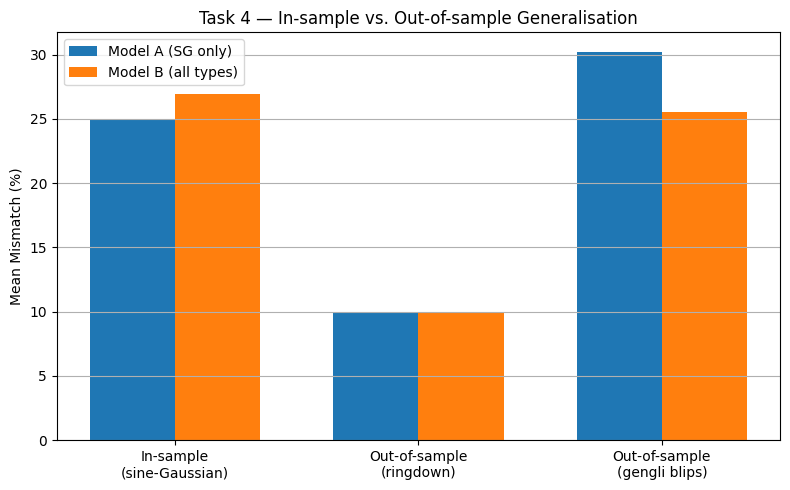

In [ ]:
# Task 4 summary: grouped bar chart
_cats = ["In-sample\n(sine-Gaussian)", "Out-of-sample\n(ringdown)"]
_mA   = [mm_A_sg * 100, mm_A_rd * 100]
_mB   = [mm_B_sg * 100, mm_B_rd * 100]

if mm_A_bl is not None:
    _cats.append("Out-of-sample\n(gengli blips)")
    _mA.append(mm_A_bl * 100)
    _mB.append(mm_B_bl * 100)

x   = np.arange(len(_cats))
w   = 0.35
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - w / 2, _mA, w, label="Model A (SG only)", color="C0")
ax.bar(x + w / 2, _mB, w, label="Model B (all types)", color="C1")
ax.set_xticks(x)
ax.set_xticklabels(_cats)
ax.set_ylabel("Mean Mismatch (%)")
ax.set_title("Task 4 — In-sample vs. Out-of-sample Generalisation")
ax.legend()
ax.grid(axis="y")
plt.tight_layout()
plt.show()

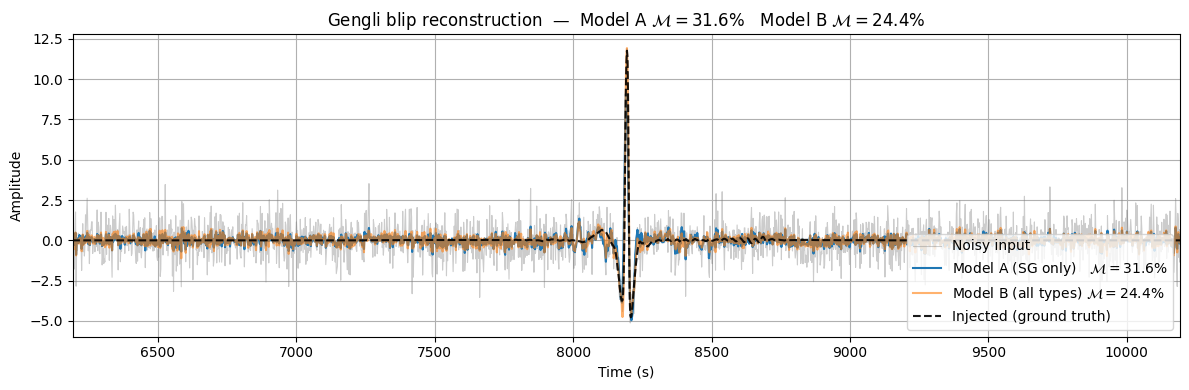

In [ ]:
# --- Gengli blip: single reconstruction example (both models + ground truth) --
if GENGLI_AVAILABLE and len(_bl_n) > 0:
    _ex_noisy = _bl_n[0]
    _ex_inj   = _bl_ij[0]
    t_axis    = np.arange(LENGTH) * DT

    _r_A    = reconstruct(_ex_noisy, model_A, scaler, DEVICE, N_FFT, HOP_LENGTH, WIN_LENGTH)
    _r_B    = reconstruct(_ex_noisy, model_B, scaler, DEVICE, N_FFT, HOP_LENGTH, WIN_LENGTH)
    mm_ex_A = 1.0 - overlap(_ex_inj, _r_A)
    mm_ex_B = 1.0 - overlap(_ex_inj, _r_B)

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(t_axis, _ex_noisy, color="gray",  lw=0.8, alpha=0.4, label="Noisy input")
    ax.plot(t_axis, _r_A,     color="C0",    lw=1.5,
            label=f"Model A (SG only)   $\\mathcal{{M}}={mm_ex_A*100:.1f}\\%$")
    ax.plot(t_axis, _r_B,     color="C1",    lw=1.5, alpha=0.6,
            label=f"Model B (all types) $\\mathcal{{M}}={mm_ex_B*100:.1f}\\%$")
    ax.plot(t_axis, _ex_inj,  color="black", lw=1.5, ls="--", alpha=0.9,
            label="Injected (ground truth)")
    ax.set_title(
        f"Gengli blip reconstruction  —  "
        f"Model A $\\mathcal{{M}}={mm_ex_A*100:.1f}\\%$   "
        f"Model B $\\mathcal{{M}}={mm_ex_B*100:.1f}\\%$"
    )
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Amplitude")
    ax.legend(loc="lower right")
    ax.set_xlim(T_PHYSICAL / 2 - 2000, T_PHYSICAL / 2 + 2000)
    ax.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print("gengli not available or no blip examples generated — skipping plot.")

---

# Part III — MC-Dropout Uncertainty Showcase

Every model trained above — the baseline `model`/`model_1d`, and every model in Tasks 1, 3, and 4 —
was already trained with `dropout_p=DROPOUT_P` (0.1, decoder + bottleneck only, never the encoder).
**Monte Carlo Dropout** works by leaving dropout *on* at test time — instead of the usual practice
of disabling it — and running many stochastic forward passes. Each pass uses a different dropout
mask, so the spread across passes gives an approximate uncertainty estimate on the reconstruction,
not just a single point estimate.

Because dropout was already baked in during training, this section needs **no separate training
run** — it simply reuses the already-trained `model` (UNET2D, from Step 3/4) and `model_1d`
(UNET1D, from Task 2) and flips dropout back on for inference. (Run Task 2 above first if you
haven't — `model_1d` is defined there.)

This section tests both on a real `gengli`-generated H1 blip glitch.

In [ ]:
def enable_mc_dropout(model):
    """Set all Dropout1d/Dropout2d modules to train mode while leaving everything
    else (e.g. BatchNorm, which should keep using its running stats) in eval mode.
    Call this after model.eval()."""
    for module in model.modules():
        if isinstance(module, (nn.Dropout1d, nn.Dropout2d)):
            module.train()


@torch.no_grad()
def mc_predict(model, x, n_passes=50, postprocess_fn=None):
    """Run n_passes stochastic forward passes (a different dropout mask each time),
    batched into a single forward call for speed. Returns samples with shape
    (n_passes, *output_shape) — optionally post-processed (e.g. iSTFT, since phase
    is circular and shouldn't be averaged directly in the STFT domain) before
    stacking across passes."""
    N = x.shape[0]
    repeat_dims = (n_passes,) + (1,) * (x.dim() - 1)
    x_rep = x.repeat(*repeat_dims)
    raw_flat = model(x_rep)
    raw = raw_flat.view(n_passes, N, *raw_flat.shape[1:])
    if postprocess_fn is not None:
        merged = raw.view(n_passes * N, *raw.shape[2:])
        processed = postprocess_fn(merged)
        return processed.view(n_passes, N, *processed.shape[1:])
    return raw

### Reuse the already-trained models — dropout is already baked in

In [ ]:
# No new training here — model and model_1d were already trained above with
# dropout_p=DROPOUT_P baked in. We just reuse them and flip dropout on at test time.
model_mc_2d = model
model_mc_1d = model_1d
print(f"Reusing already-trained UNET2D and UNET1D models (dropout_p={DROPOUT_P}).")

Reusing already-trained UNET2D and UNET1D models (dropout_p=0.1).


### Fetch a real gengli H1 blip glitch and inject it

In [ ]:
if GENGLI_AVAILABLE:
    _mc_noise = generate_gaussian_noise(mean, std_dev, 1, (LENGTH,), bilby_noise=False)[0]
    _mc_blip  = np.array(_ggen.get_glitch(1, srate=4096, snr=10, alpha=0.2, fhigh=1024)).squeeze()
    _mc_blip  = _mc_blip - np.mean(_mc_blip)
    _mc_blip  = whitened_snr_scaling(_mc_blip, snr=30)
    _mc_L     = min(len(_mc_blip), LENGTH)
    _mc_i0    = max(0, int(T_INJ * SAMPLE_RATE) - _mc_L // 2)
    _mc_i0    = min(_mc_i0, LENGTH - _mc_L)

    mc_noisy = _mc_noise.copy()
    mc_noisy[_mc_i0:_mc_i0 + _mc_L] += _mc_blip[:_mc_L]
    mc_inj = np.zeros(LENGTH)
    mc_inj[_mc_i0:_mc_i0 + _mc_L] = _mc_blip[:_mc_L]
    print("Gengli blip injected, ready for MC-Dropout reconstruction.")
else:
    print("gengli not available — skipping MC-Dropout showcase.")

Generating noise...
Gengli blip injected, ready for MC-Dropout reconstruction.


### MC-Dropout inference — both models, dropout left on at test time

In [ ]:
if GENGLI_AVAILABLE:
    n_mc_passes = 100
    window_mc = torch.hann_window(WIN_LENGTH)

    def istft_from_spec(spec_batch):
        mag, phase = spec_batch[:, 0], spec_batch[:, 1]
        complex_spec = (mag * torch.exp(1j * phase)).cpu()  # istft runs on CPU, matching window_mc
        return torch.istft(complex_spec, n_fft=N_FFT, hop_length=HOP_LENGTH,
                           win_length=WIN_LENGTH, window=window_mc, length=LENGTH)

    # --- UNET2D: deterministic reconstruction (dropout off) for comparison ------
    det_recon_2d = reconstruct(mc_noisy, model_mc_2d, scaler, DEVICE, N_FFT, HOP_LENGTH, WIN_LENGTH)

    # --- UNET2D: MC-Dropout (dropout left on) ------------------------------------
    scaled_2d = scaler.transform(mc_noisy.reshape(-1, 1)).reshape(1, -1)
    t_2d = torch.tensor(scaled_2d, dtype=torch.float32)
    stft_2d = torch.stft(t_2d, n_fft=N_FFT, hop_length=HOP_LENGTH, win_length=WIN_LENGTH,
                         window=window_mc, return_complex=True)
    spec_2d = torch.stack([torch.abs(stft_2d), torch.angle(stft_2d)], dim=1).to(DEVICE)

    model_mc_2d.eval()
    enable_mc_dropout(model_mc_2d)
    samples_2d_scaled = mc_predict(model_mc_2d, spec_2d, n_passes=n_mc_passes,
                                   postprocess_fn=istft_from_spec)
    samples_2d_scaled = samples_2d_scaled.squeeze(1).cpu().numpy()          # (n_passes, LENGTH)
    bg_samples_2d = scaler.inverse_transform(
        samples_2d_scaled.reshape(-1, 1)).reshape(samples_2d_scaled.shape)  # unscaled background, per pass
    residual_samples_2d = mc_noisy[None, :] - bg_samples_2d                 # extracted glitch, per pass

    # --- UNET1D: deterministic reconstruction (dropout off) for comparison ------
    model_mc_1d.eval()
    with torch.no_grad():
        _sc_1d = scaler.transform(mc_noisy.reshape(-1, 1)).reshape(1, 1, -1)
        _out_1d = model_mc_1d(torch.tensor(_sc_1d, dtype=torch.float32).to(DEVICE)).cpu().numpy().squeeze()
    det_bg_1d = scaler.inverse_transform(_out_1d.reshape(-1, 1)).reshape(-1)
    det_recon_1d = mc_noisy - det_bg_1d

    # --- UNET1D: MC-Dropout (dropout left on) ------------------------------------
    enable_mc_dropout(model_mc_1d)
    scaled_1d = scaler.transform(mc_noisy.reshape(-1, 1)).reshape(1, 1, -1)
    x_1d = torch.tensor(scaled_1d, dtype=torch.float32).to(DEVICE)
    samples_1d_scaled = mc_predict(model_mc_1d, x_1d, n_passes=n_mc_passes)         # (n_passes, 1, 1, LENGTH)
    samples_1d_scaled = samples_1d_scaled.squeeze(1).squeeze(1).cpu().numpy()       # (n_passes, LENGTH)
    bg_samples_1d = scaler.inverse_transform(
        samples_1d_scaled.reshape(-1, 1)).reshape(samples_1d_scaled.shape)
    residual_samples_1d = mc_noisy[None, :] - bg_samples_1d

    print(f"MC-Dropout: {n_mc_passes} passes each, UNET2D and UNET1D.")
else:
    print("gengli not available — skipping MC-Dropout inference.")

MC-Dropout: 100 passes each, UNET2D and UNET1D.


### Plot: MC-Dropout mean ± uncertainty vs. deterministic reconstruction

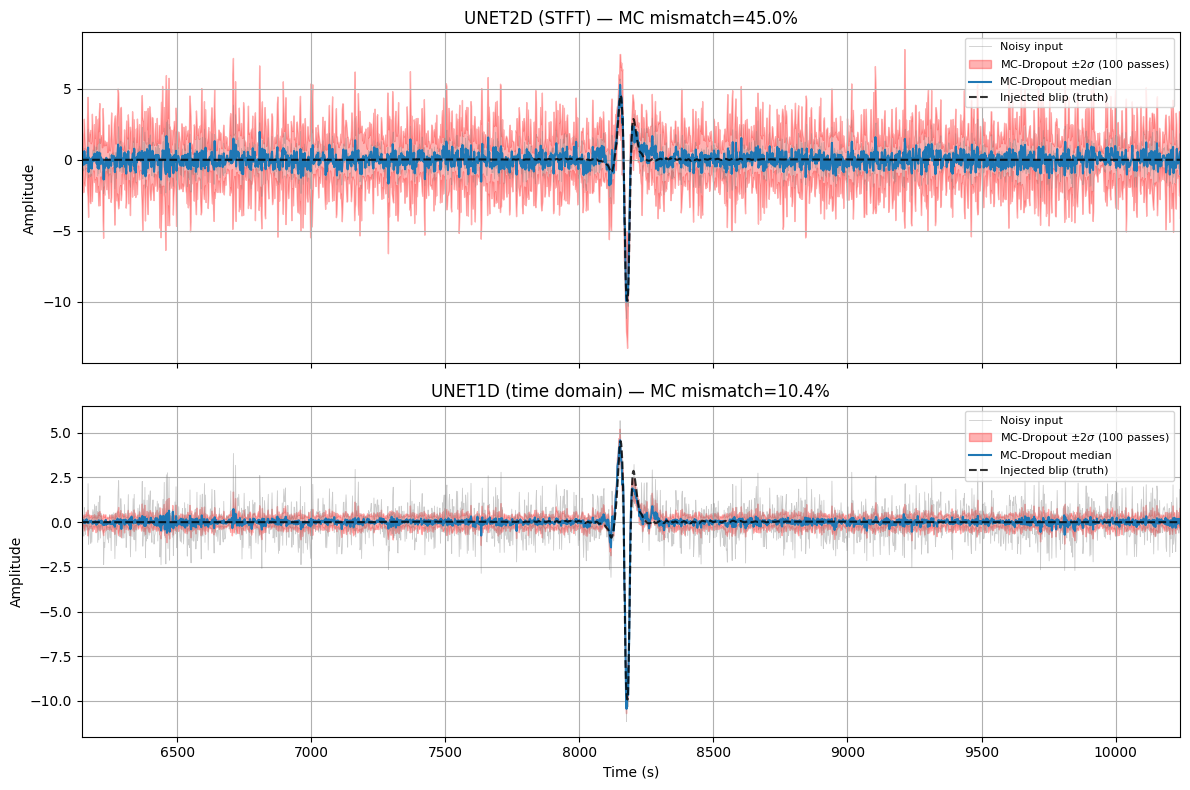

In [ ]:
if GENGLI_AVAILABLE:
    t_axis_mc = np.arange(LENGTH) * DT

    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    _zoom_half = 1024  # zoom to the middle 2048 samples (out of LENGTH), centered on the injection
    _zoom_lo, _zoom_hi = LENGTH // 2 - _zoom_half, LENGTH // 2 + _zoom_half

    for ax, residual_samples, label in [
        (axes[0], residual_samples_2d, "UNET2D (STFT)"),
        (axes[1], residual_samples_1d, "UNET1D (time domain)"),
    ]:
        mc_median = np.median(residual_samples, axis=0)
        mc_std  = residual_samples.std(axis=0)

        ax.plot(t_axis_mc, mc_noisy, color="gray", lw=0.6, alpha=0.4, label="Noisy input")
        ax.fill_between(t_axis_mc, mc_median - 2 * mc_std, mc_median + 2 * mc_std,
                        color="red", alpha=0.3, label=f"MC-Dropout $\\pm2\\sigma$ ({n_mc_passes} passes)")
        ax.plot(t_axis_mc, mc_median, color="C0", lw=1.5, label="MC-Dropout median")
        ax.plot(t_axis_mc, mc_inj, color="black", lw=1.5, ls="--", alpha=0.8, label="Injected blip (truth)")

        mm_mc  = 1.0 - overlap(mc_inj, mc_median)
        ax.set_title(f"{label} — MC mismatch={mm_mc*100:.1f}%")
        ax.set_ylabel("Amplitude")
        ax.legend(fontsize=8, loc="upper right")
        ax.grid(True)
        ax.set_xlim(t_axis_mc[_zoom_lo], t_axis_mc[_zoom_hi])

    axes[-1].set_xlabel("Time (s)")
    plt.tight_layout()
    plt.show()
else:
    print("gengli not available — skipping MC-Dropout showcase plot.")

---

# Part IV — Bonus: Reconstructing a Real CBC Waveform (PyCBC)

Every signal used so far (the five basis waveforms, the gengli blip) is either fully
synthetic or a learned detector-glitch model. This section instead generates a real
compact-binary-coalescence (CBC) waveform with `pycbc`/`lalsimulation` — genuine
inspiral-merger-ringdown physics, not a hand-rolled approximation.

A real stellar-mass BBH waveform spans far more samples than our `LENGTH` window even
after trimming its zero-padding, so trimming + a mild resample compresses it to fit —
which reproduces the qualitative *shape* of a much longer, lower-frequency coalescence
(e.g. a massive black hole binary, MBHB): a long, slowly growing inspiral, a fast
merger, and a brief ringdown. It is not a physically exact MBHB waveform (real MBHBs
merge over hours-to-days at LISA frequencies), but the morphology is the same.

Uses only the STFT `UNET2D` model (`model`, already trained in Step 3/4) with
MC-Dropout left on at test time — no new training, same pattern as Part III.

In [ ]:
!pip install pycbc

In [ ]:
try:
    from pycbc.waveform import get_td_waveform
    PYCBC_AVAILABLE = True
    print("pycbc available.")
except ImportError:
    PYCBC_AVAILABLE = False
    print("pycbc not available — skipping the CBC reconstruction bonus section.")

if PYCBC_AVAILABLE:
    from scipy.signal import resample

    # A real BBH waveform (mass1=30, mass2=25 solar masses) generated at our own
    # sample rate. pycbc internally pads to a power-of-two length far longer than
    # our LENGTH=8192 window, so trim the near-zero padding first, then resample
    # the meaningful part down to exactly LENGTH samples.
    hp, _ = get_td_waveform(approximant="IMRPhenomD", mass1=30, mass2=25,
                            delta_t=1.0 / SAMPLE_RATE, f_lower=30)
    _cbc_raw = hp.numpy()
    _cbc_thresh = 1e-4 * np.max(np.abs(_cbc_raw))
    _cbc_nz = np.where(np.abs(_cbc_raw) > _cbc_thresh)[0]
    _cbc_trimmed = _cbc_raw[_cbc_nz[0]:_cbc_nz[-1] + 1]

    cbc_waveform = resample(_cbc_trimmed, LENGTH)
    cbc_waveform = cbc_waveform - np.mean(cbc_waveform)
    cbc_waveform = whitened_snr_scaling(cbc_waveform, snr=30)

    cbc_noise = generate_gaussian_noise(mean, std_dev, 1, (LENGTH,), bilby_noise=False)[0]
    cbc_noisy = cbc_noise + cbc_waveform
    cbc_inj   = cbc_waveform.copy()

    print(f"CBC waveform ready: {len(_cbc_trimmed)} samples trimmed -> resampled to {LENGTH}.")

PyCBC.libutils: pkg-config call failed, setting NO_PKGCONFIG=1


pycbc available.
Generating noise...
CBC waveform ready: 8033 samples trimmed -> resampled to 8192.


### MC-Dropout reconstruction — STFT model only

In [ ]:
if PYCBC_AVAILABLE:
    n_mc_passes_cbc = 100
    window_cbc = torch.hann_window(WIN_LENGTH)

    def istft_from_spec_cbc(spec_batch):
        mag, phase = spec_batch[:, 0], spec_batch[:, 1]
        complex_spec = (mag * torch.exp(1j * phase)).cpu()  # istft runs on CPU, matching window_cbc
        return torch.istft(complex_spec, n_fft=N_FFT, hop_length=HOP_LENGTH,
                           win_length=WIN_LENGTH, window=window_cbc, length=LENGTH)

    scaled_cbc = scaler.transform(cbc_noisy.reshape(-1, 1)).reshape(1, -1)
    t_cbc = torch.tensor(scaled_cbc, dtype=torch.float32)
    stft_cbc = torch.stft(t_cbc, n_fft=N_FFT, hop_length=HOP_LENGTH, win_length=WIN_LENGTH,
                          window=window_cbc, return_complex=True)
    spec_cbc = torch.stack([torch.abs(stft_cbc), torch.angle(stft_cbc)], dim=1).to(DEVICE)

    model.eval()
    enable_mc_dropout(model)
    samples_cbc_scaled = mc_predict(model, spec_cbc, n_passes=n_mc_passes_cbc,
                                    postprocess_fn=istft_from_spec_cbc)
    samples_cbc_scaled = samples_cbc_scaled.squeeze(1).cpu().numpy()          # (n_passes, LENGTH)
    bg_samples_cbc = scaler.inverse_transform(
        samples_cbc_scaled.reshape(-1, 1)).reshape(samples_cbc_scaled.shape)  # unscaled background, per pass
    residual_samples_cbc = cbc_noisy[None, :] - bg_samples_cbc                # extracted signal, per pass

    print(f"MC-Dropout CBC reconstruction ready ({n_mc_passes_cbc} passes).")

MC-Dropout CBC reconstruction ready (100 passes).


### Plot: MC-Dropout median ± uncertainty

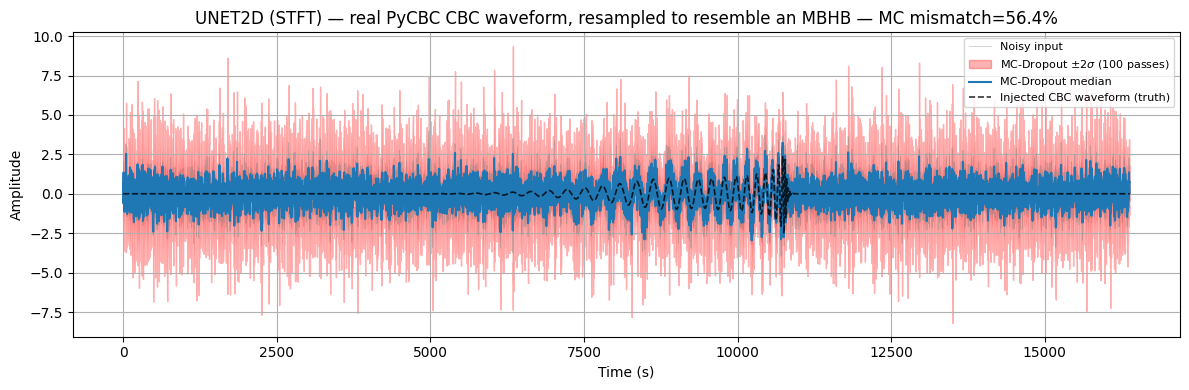

In [ ]:
if PYCBC_AVAILABLE:
    t_axis_cbc = np.arange(LENGTH) * DT

    cbc_median = np.median(residual_samples_cbc, axis=0)
    cbc_std    = residual_samples_cbc.std(axis=0)

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(t_axis_cbc, cbc_noisy, color="gray", lw=0.6, alpha=0.4, label="Noisy input")
    ax.fill_between(t_axis_cbc, cbc_median - 2 * cbc_std, cbc_median + 2 * cbc_std,
                    color="red", alpha=0.3, label=f"MC-Dropout $\\pm2\\sigma$ ({n_mc_passes_cbc} passes)")
    ax.plot(t_axis_cbc, cbc_median, color="C0", lw=1.5, label="MC-Dropout median")
    ax.plot(t_axis_cbc, cbc_inj, color="black", lw=1.2, ls="--", alpha=0.8, label="Injected CBC waveform (truth)")

    mm_cbc = 1.0 - overlap(cbc_inj, cbc_median)
    ax.set_title(f"UNET2D (STFT) — real PyCBC CBC waveform, resampled to resemble an MBHB — "
                f"MC mismatch={mm_cbc*100:.1f}%")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Amplitude")
    ax.legend(fontsize=8, loc="upper right")
    ax.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print("pycbc not available — skipping CBC reconstruction plot.")

### Plot: deterministic reconstruction (dropout off), for comparison. Deterministic model is far better due to the MC model not being trained to convergence. This leads to large sensitivity using the dropout in this case for uncertainty quantification.

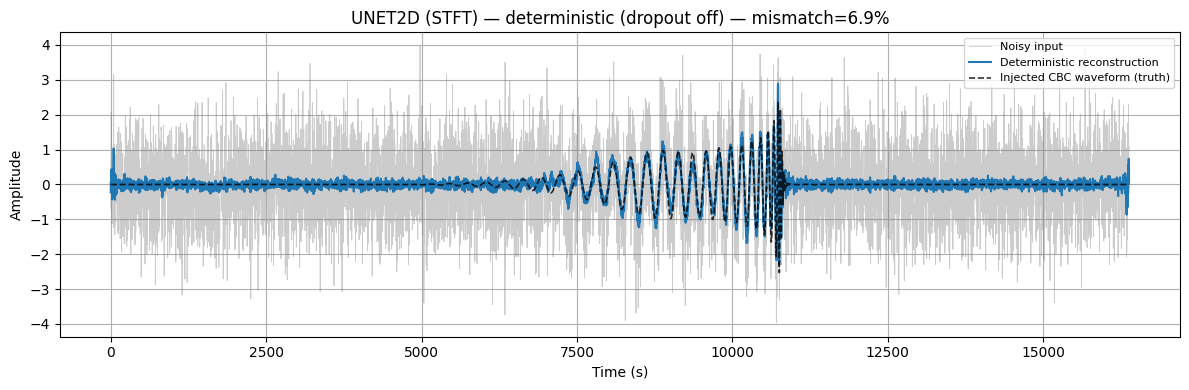

In [ ]:
if PYCBC_AVAILABLE:
    det_recon_cbc = reconstruct(cbc_noisy, model, scaler, DEVICE, N_FFT, HOP_LENGTH, WIN_LENGTH)

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(t_axis_cbc, cbc_noisy, color="gray", lw=0.6, alpha=0.4, label="Noisy input")
    ax.plot(t_axis_cbc, det_recon_cbc, color="C0", lw=1.5, label="Deterministic reconstruction")
    ax.plot(t_axis_cbc, cbc_inj, color="black", lw=1.2, ls="--", alpha=0.8, label="Injected CBC waveform (truth)")

    mm_det_cbc = 1.0 - overlap(cbc_inj, det_recon_cbc)
    ax.set_title(f"UNET2D (STFT) — deterministic (dropout off) — mismatch={mm_det_cbc*100:.1f}%")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Amplitude")
    ax.legend(fontsize=8, loc="upper right")
    ax.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print("pycbc not available — skipping deterministic CBC reconstruction plot.")